# Roteiro 2 — Classificação supervisionada de intrusão

**Cibersegurança Aplicada com Inteligência Artificial · Insper 2026-2**

**Dupla:** _Antonio Almeida_ e _Luka Figueiredo_  
**Data:** _27/08/2026_

---
## Ambiente

Versões das bibliotecas usadas, para reprodutibilidade da correção.

In [1]:
# Versões das bibliotecas — garante que o notebook é reprodutível por quem corrigir.
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print(f"Python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")

Python      : 3.11.9
numpy       : 1.26.4
pandas      : 3.0.5
scikit-learn: 1.9.0
matplotlib  : 3.11.1


---
## a) Gerar o dataset da dupla

Comando executado:

```bash
python meu_dataset.py -dupla "Antonio Almeida; Luka Figueiredo"
```

Saída completa do script colada abaixo.

```bash
Código da dupla : d23bda
random_state    : 3527138017   <- use este valor em TODO train_test_split / modelo
Arquivo         : dados/R2_d23bda.csv.gz  (111679 fluxos x 83 colunas)
Classe difícil  : DoS lento (slowloris + Slowhttptest)   -> rótulos ['DoS slowloris', 'DoS Slowhttptest']

Distribuição de rótulos:
 Label
BENIGN                        64246
DDoS                           8695
PortScan                       8677
DoS Hulk                       8564
FTP-Patator                    3678
SSH-Patator                    3606
DoS slowloris                  3544
DoS Slowhttptest               3367
DoS GoldenEye                  3055
Bot                            1989
Web Attack - Brute Force       1530
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11
```

In [2]:
# Parâmetros da dupla, extraídos da saída do meu_dataset.py.
# O RANDOM_STATE é obrigatório em TODO split e TODO modelo deste roteiro.

CODIGO_DUPLA = "d23bda"
RANDOM_STATE = 3527138017
CLASSE_DIFICIL = ['DoS slowloris', 'DoS Slowhttptest']

ARQUIVO_AQUECIMENTO = "dados/dados/aquecimento_autenticacao.csv"
ARQUIVO_R2 = f"dados/dados/R2_{CODIGO_DUPLA}.csv.gz"

print(f"Código da dupla : {CODIGO_DUPLA}")
print(f"random_state    : {RANDOM_STATE}")
print(f"Classe difícil  : {CLASSE_DIFICIL}")
print(f"Arquivo do núcleo: {ARQUIVO_R2}")

Código da dupla : d23bda
random_state    : 3527138017
Classe difícil  : ['DoS slowloris', 'DoS Slowhttptest']
Arquivo do núcleo: dados/dados/R2_d23bda.csv.gz


In [3]:
# Confere que os arquivos existem antes de seguir para o item b).
from pathlib import Path

for caminho in (ARQUIVO_AQUECIMENTO, ARQUIVO_R2):
    p = Path(caminho)
    tamanho = f"{p.stat().st_size / 1e6:.1f} MB" if p.exists() else "AUSENTE"
    print(f"{'OK ' if p.exists() else 'ERRO'} | {caminho} | {tamanho}")

OK  | dados/dados/aquecimento_autenticacao.csv | 0.2 MB
OK  | dados/dados/R2_d23bda.csv.gz | 11.9 MB


---
## b) Aquecimento: carregar, X/y e baseline heurístico

`aquecimento_autenticacao.csv` — 3.160 IPs, 8 sinais de autenticação em janela de
24h, rótulo `benigno` / `brute_force`. Fluxo completo em dados limpos antes do
CICIDS2017 real.

### **b.1** — Carga e visão geral

In [4]:
aquec = pd.read_csv(ARQUIVO_AQUECIMENTO)

print("shape:", aquec.shape)
print("\ncolunas:", list(aquec.columns))
print("\nvalores ausentes por coluna:")
print(aquec.isna().sum())

aquec.head()

shape: (3160, 10)

colunas: ['ip_origem', 'tentativas_total', 'falhas', 'usuarios_distintos', 'intervalo_medio_seg', 'fracao_noturna', 'usuarios_inexistentes', 'sucesso_apos_falhas', 'portas_distintas', 'label']

valores ausentes por coluna:
ip_origem                0
tentativas_total         0
falhas                   0
usuarios_distintos       0
intervalo_medio_seg      0
fracao_noturna           0
usuarios_inexistentes    0
sucesso_apos_falhas      0
portas_distintas         0
label                    0
dtype: int64


,ip_origem,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas,label
0,10.167.247.77,7,2,1,3246.7,0.326,0,1,2,benigno
1,10.150.85.49,9,0,1,3971.1,0.038,0,0,1,benigno
2,10.197.165.65,8,1,1,4069.9,0.490,0,0,1,benigno
3,10.224.190.222,5,1,1,3795.9,0.038,0,0,2,benigno
4,10.171.145.87,5,1,1,4997.1,0.111,0,0,1,benigno


### **b.2** — Distribuição do rótulo e proporção de ataque

In [5]:
contagem = aquec["label"].value_counts()
proporcao = aquec["label"].value_counts(normalize=True)

print("Contagem de rótulos:")
print(contagem)
print("\nProporção:")
print((proporcao * 100).round(2).astype(str) + " %")

Contagem de rótulos:
label
benigno        2600
brute_force     560
Name: count, dtype: int64

Proporção:
label
benigno        82.28 %
brute_force    17.72 %
Name: proportion, dtype: str


In [6]:
TAXA_ATAQUE = proporcao.get("brute_force", 0.0)
print(f"\nProporção de ataque: {TAXA_ATAQUE:.4f}  ({TAXA_ATAQUE*100:.2f} %)")
print(f"Baseline trivial ('tudo benigno'): acurácia = {1 - TAXA_ATAQUE:.4f}")


Proporção de ataque: 0.1772  (17.72 %)
Baseline trivial ('tudo benigno'): acurácia = 0.8228


560 ataques em 3.160 IPs: **17,72 %**. Baseline trivial ("tudo benigno") =
**82,28 %** de acurácia. Toda avaliação adiante é lida com FN, FP e recall da
classe de ataque, não com acurácia isolada.

### **b.3** — Escala das features

In [7]:
# describe() completo (pedido pelo roteiro)
display(aquec.describe())

# Visão focada em escala: é isso que justifica o StandardScaler no item d).
escala = aquec.drop(columns=["ip_origem", "label"]).describe().T[["mean", "std", "min", "max"]]
escala["amplitude"] = escala["max"] - escala["min"]
escala.sort_values("amplitude", ascending=False).round(3)

,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas
count,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000
mean,36.109810,24.590506,5.183544,3024.134873,0.260418,1.657278,0.264557,1.287025
std,66.804731,60.669297,8.996984,2076.488208,0.229931,4.214637,0.441167,0.517704
min,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,0.000000,1.000000,1638.000000,0.085750,0.000000,0.000000,1.000000
50%,8.000000,1.000000,2.000000,2871.000000,0.184000,0.000000,0.000000,1.000000
75%,12.000000,2.000000,3.000000,4227.275000,0.366000,0.000000,1.000000,2.000000
max,236.000000,227.000000,46.000000,15724.600000,0.969000,23.000000,1.000000,3.000000


,mean,std,min,max,amplitude
intervalo_medio_seg,3024.135,2076.488,0.2,15724.600,15724.400
tentativas_total,36.110,66.805,1.0,236.000,235.000
falhas,24.591,60.669,0.0,227.000,227.000
usuarios_distintos,5.184,8.997,1.0,46.000,45.000
usuarios_inexistentes,1.657,4.215,0.0,23.000,23.000
portas_distintas,1.287,0.518,1.0,3.000,2.000
sucesso_apos_falhas,0.265,0.441,0.0,1.000,1.000
fracao_noturna,0.260,0.230,0.0,0.969,0.969


Escalas incomparáveis: `intervalo_medio_seg` tem amplitude 15.724,4 contra 0,969
de `fracao_noturna` — razão de ~16.000×. Irrelevante para a árvore (item c),
determinante para a regressão logística (item d).

### **b.4** — Separar X e y

In [8]:
# ip_origem é identificador, não comportamento -> fora das features.
X = aquec.drop(columns=["ip_origem", "label"])
y = (aquec["label"] == "brute_force").astype(int)   # 1 = ataque, 0 = benigno

print("X:", X.shape, "| y:", y.shape)
print("\nBalanço de y:")
print(y.value_counts().rename({0: "benigno (0)", 1: "brute_force (1)"}))
print("\nFeatures usadas:", list(X.columns))

X: (3160, 8) | y: (3160,)

Balanço de y:
label
benigno (0)        2600
brute_force (1)     560
Name: count, dtype: int64

Features usadas: ['tentativas_total', 'falhas', 'usuarios_distintos', 'intervalo_medio_seg', 'fracao_noturna', 'usuarios_inexistentes', 'sucesso_apos_falhas', 'portas_distintas']


`y` é binário: 1 = `brute_force`, 0 = `benigno`. `X` fica com os 8 sinais
comportamentais.

`ip_origem` foi excluído das features porque é **identificador, não
comportamento**. Há um IP por linha, então a coluna é uma chave única: uma árvore
consegue memorizar o mapa IP → rótulo e chegar a ~1,00 de acurácia no treino sem
aprender nada sobre o que caracteriza um ataque. O que o modelo guardaria é a
identidade dos 560 atacantes deste arquivo. Em produção, todo IP observado é um
valor nunca visto no treino, e o modelo cai para o comportamento padrão do nó
onde a linha parar — o desempenho medido viraria ficção.


### **b.5** — A regra manual

--- Regra manual (falhas>=10 & usuarios_inexistentes>=1) ---
acurácia: 0.9595
TN=2583  FP=17  FN=111  TP=449
recall(ataque)=0.8018  precisão(ataque)=0.9635


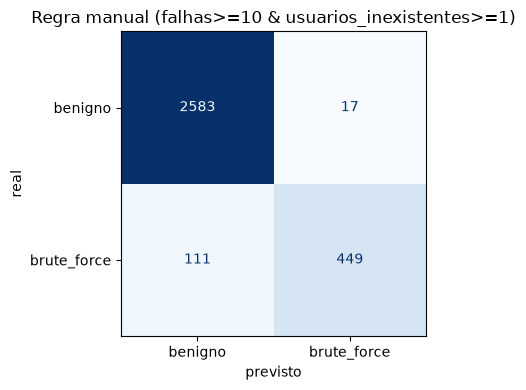

              precision    recall  f1-score   support

     benigno       0.96      0.99      0.98      2600
 brute_force       0.96      0.80      0.88       560

    accuracy                           0.96      3160
   macro avg       0.96      0.90      0.93      3160
weighted avg       0.96      0.96      0.96      3160



In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ROT = {0: "benigno", 1: "brute_force"}

def plot_matriz(y_true, y_pred, titulo, classes=None, normalizar=False, figsize=(5, 4)):
    """Matriz de confusão como imagem. Serve para 2 e para 15 classes."""
    fig, ax = plt.subplots(figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, labels=classes,
        normalize="true" if normalizar else None,
        values_format=".2f" if normalizar else "d",
        cmap="Blues", colorbar=False, ax=ax,
        xticks_rotation=45 if classes is not None and len(classes) > 4 else "horizontal",
    )
    ax.set_title(titulo)
    ax.set_xlabel("previsto"); ax.set_ylabel("real")
    plt.tight_layout()
    plt.show()

def avaliar_regra(mascara, y_true, nome="regra", plotar=True):
    """Avalia uma máscara booleana pandas como se fosse um classificador."""
    y_pred = mascara.astype(int)
    acc = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"--- {nome} ---")
    print(f"acurácia: {acc:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"recall(ataque)={tp/(tp+fn):.4f}  precisão(ataque)={tp/(tp+fp) if tp+fp else float('nan'):.4f}")
    if plotar:
        plot_matriz(y_true.map(ROT), y_pred.map(ROT), nome,
                    classes=["benigno", "brute_force"])
    print(classification_report(y_true, y_pred, target_names=["benigno", "brute_force"]))
    return {"nome": nome, "acuracia": acc, "TN": tn, "FP": fp, "FN": fn, "TP": tp}

# Regra no estilo do Roteiro 1. Limiares definidos por leitura do describe().
regra = (aquec["falhas"] >= 10) & (aquec["usuarios_inexistentes"] >= 1)

res_regra = avaliar_regra(regra, y, nome="Regra manual (falhas>=10 & usuarios_inexistentes>=1)", plotar=True)

Regra: `falhas >= 10 AND usuarios_inexistentes >= 1` — força bruta acumula falhas
em volume e, por usar listas de credenciais, tenta logins inexistentes.

Acurácia **0,9595** · TP=449 TN=2583 **FP=17 FN=111** · recall 0,8018 ·
precisão 0,9635. Conservadora: quase não gera alarme falso, perde 1 ataque em 5.

Limiares vieram do `describe()`, não de otimização contra o rótulo. A partir do
item c) todo ajuste é feito só no treino.

In [10]:
# Acumulador de resultados do aquecimento -> vira a tabela-síntese do relatório
# e a primeira seção do Anexo B. Alimentado também nos itens c) e d).
resultados_aquecimento = [res_regra]

### **b.6** — Autópsia dos erros

In [11]:
erros = aquec.loc[regra.astype(int) != y].copy()
erros["tipo_erro"] = np.where(erros["label"] == "brute_force", "FN", "FP")

print("Total de erros:", len(erros))
print(erros["tipo_erro"].value_counts(), "\n")

# Perfil médio: erros vs. acertos, por feature
perfil = pd.concat([
    aquec.loc[y == 1].drop(columns=["ip_origem", "label"]).median().rename("mediana ATAQUE"),
    aquec.loc[y == 0].drop(columns=["ip_origem", "label"]).median().rename("mediana BENIGNO"),
    erros.loc[erros.tipo_erro == "FN"].drop(columns=["ip_origem", "label", "tipo_erro"]).median().rename("mediana FN"),
    erros.loc[erros.tipo_erro == "FP"].drop(columns=["ip_origem", "label", "tipo_erro"]).median().rename("mediana FP"),
], axis=1).round(3)

display(perfil)
display(erros.sort_values("tipo_erro").head(15))

Total de erros: 128
tipo_erro
FN    111
FP     17
Name: count, dtype: int64 



,mediana ATAQUE,mediana BENIGNO,mediana FN,mediana FP
tentativas_total,193.000,7.000,10.000,16.000
falhas,175.000,1.000,8.000,13.000
usuarios_distintos,26.000,1.000,5.000,1.000
intervalo_medio_seg,3.800,3234.650,2529.500,3355.400
fracao_noturna,0.586,0.143,0.512,0.158
usuarios_inexistentes,10.000,0.000,1.000,1.000
sucesso_apos_falhas,0.000,0.000,0.000,0.000
portas_distintas,1.000,1.000,1.000,1.000


,ip_origem,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas,label,tipo_erro
3151,10.37.232.20,11,8,7,1535.4,0.198,3,0,1,brute_force,FN
2137,10.86.23.34,12,9,4,509.9,0.152,1,0,2,brute_force,FN
2136,10.239.165.69,9,7,3,1328.8,0.521,1,0,1,brute_force,FN
2119,10.222.123.10,13,9,4,696.3,0.569,2,0,1,brute_force,FN
2104,10.145.62.206,11,9,7,2371.7,0.506,1,0,1,brute_force,FN
2093,10.140.192.53,11,8,9,2740.6,0.297,1,0,1,brute_force,FN
2089,10.165.116.63,11,8,6,903.6,0.434,0,0,1,brute_force,FN
2086,10.83.185.55,11,8,5,1828.9,0.441,3,0,1,brute_force,FN
2085,10.118.52.93,12,9,5,1558.7,0.428,2,1,1,brute_force,FN
2078,10.19.144.194,7,6,4,3211.5,0.170,2,0,1,brute_force,FN


128 erros: **111 FN**, 17 FP.

FN — mediana `intervalo_medio_seg` **2.529,5 s** contra **3,8 s** do ataque
mediano; `falhas` mediana 8, logo abaixo do limiar. A condição que os reprova é
só `falhas >= 10`. Ainda assim têm `fracao_noturna` 0,512 (benigno: 0,143) e
`usuarios_distintos` 5 (benigno: 1) — o ataque está marcado em duas features que
a regra não consulta.

FP — `usuarios_distintos` = 1, `fracao_noturna` 0,158, 13 falhas em uma só conta.
Perfil de credencial expirada, não de varredura.

---
## c) — Split e árvore de decisão

### **c.1** — Split estratificado 70/30

In [12]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f"treino: {X_tr.shape[0]} linhas | ataque = {y_tr.mean():.4f}")
print(f"teste : {X_te.shape[0]} linhas | ataque = {y_te.mean():.4f}")
print(f"base  : {X.shape[0]} linhas | ataque = {y.mean():.4f}")
print(f"\nBaseline trivial no teste ('tudo benigno'): {1 - y_te.mean():.4f}")

treino: 2212 linhas | ataque = 0.1772
teste : 948 linhas | ataque = 0.1772
base  : 3160 linhas | ataque = 0.1772

Baseline trivial no teste ('tudo benigno'): 0.8228


### **c.2** — Regra manual reavaliada no conjunto de teste

A regra do item b) foi medida nas 3.160 linhas; a árvore é medida em 948. Para a
comparação do item d) ser válida, a regra é reaplicada aqui sobre o mesmo teste.

--- Regra manual (teste) ---
acurácia: 0.9684
TN=778  FP=2  FN=28  TP=140
recall(ataque)=0.8333  precisão(ataque)=0.9859


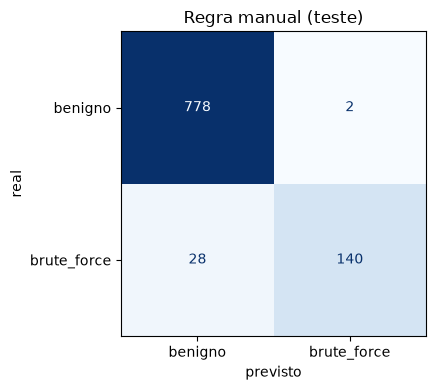

              precision    recall  f1-score   support

     benigno       0.97      1.00      0.98       780
 brute_force       0.99      0.83      0.90       168

    accuracy                           0.97       948
   macro avg       0.98      0.92      0.94       948
weighted avg       0.97      0.97      0.97       948



In [13]:
# A regra não "treina", mas precisa ser medida no MESMO conjunto que os modelos.
regra_teste = (X_te["falhas"] >= 10) & (X_te["usuarios_inexistentes"] >= 1)
res_regra_te = avaliar_regra(regra_teste, y_te, nome="Regra manual (teste)")

resultados_aquecimento.append(res_regra_te)

### **c.3** — Árvore de decisão (max_depth=3)

--- Árvore d=3 ---
acurácia: 0.9979
TN=780  FP=0  FN=2  TP=166
recall(ataque)=0.9881  precisão(ataque)=1.0000
              precision    recall  f1-score   support

     benigno       1.00      1.00      1.00       780
 brute_force       1.00      0.99      0.99       168

    accuracy                           1.00       948
   macro avg       1.00      0.99      1.00       948
weighted avg       1.00      1.00      1.00       948



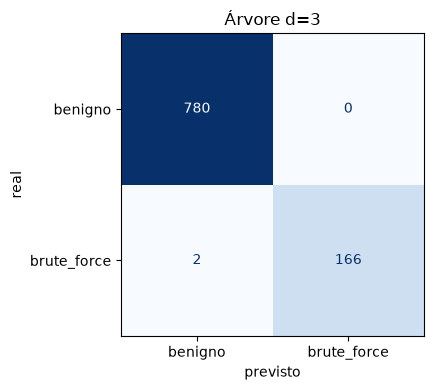

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def avaliar_modelo(modelo, X_te, y_te, nome, plotar=True):
    """Mesma saída de avaliar_regra, para modelos sklearn já treinados."""
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    print(f"--- {nome} ---")
    print(f"acurácia: {acc:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"recall(ataque)={tp/(tp+fn):.4f}  precisão(ataque)={tp/(tp+fp) if tp+fp else float('nan'):.4f}")
    print(classification_report(y_te, y_pred, target_names=["benigno", "brute_force"]))
    if plotar:
        plot_matriz(pd.Series(y_te).map(ROT), pd.Series(y_pred).map(ROT), nome,
                    classes=["benigno", "brute_force"])
    return {"nome": nome, "acuracia": acc, "TN": tn, "FP": fp, "FN": fn, "TP": tp}

arvore = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
arvore.fit(X_tr, y_tr)   # aprende SÓ no treino

res_arvore = avaliar_modelo(arvore, X_te, y_te, "Árvore d=3")
resultados_aquecimento.append(res_arvore)

### **c.4** — Desenho da árvore

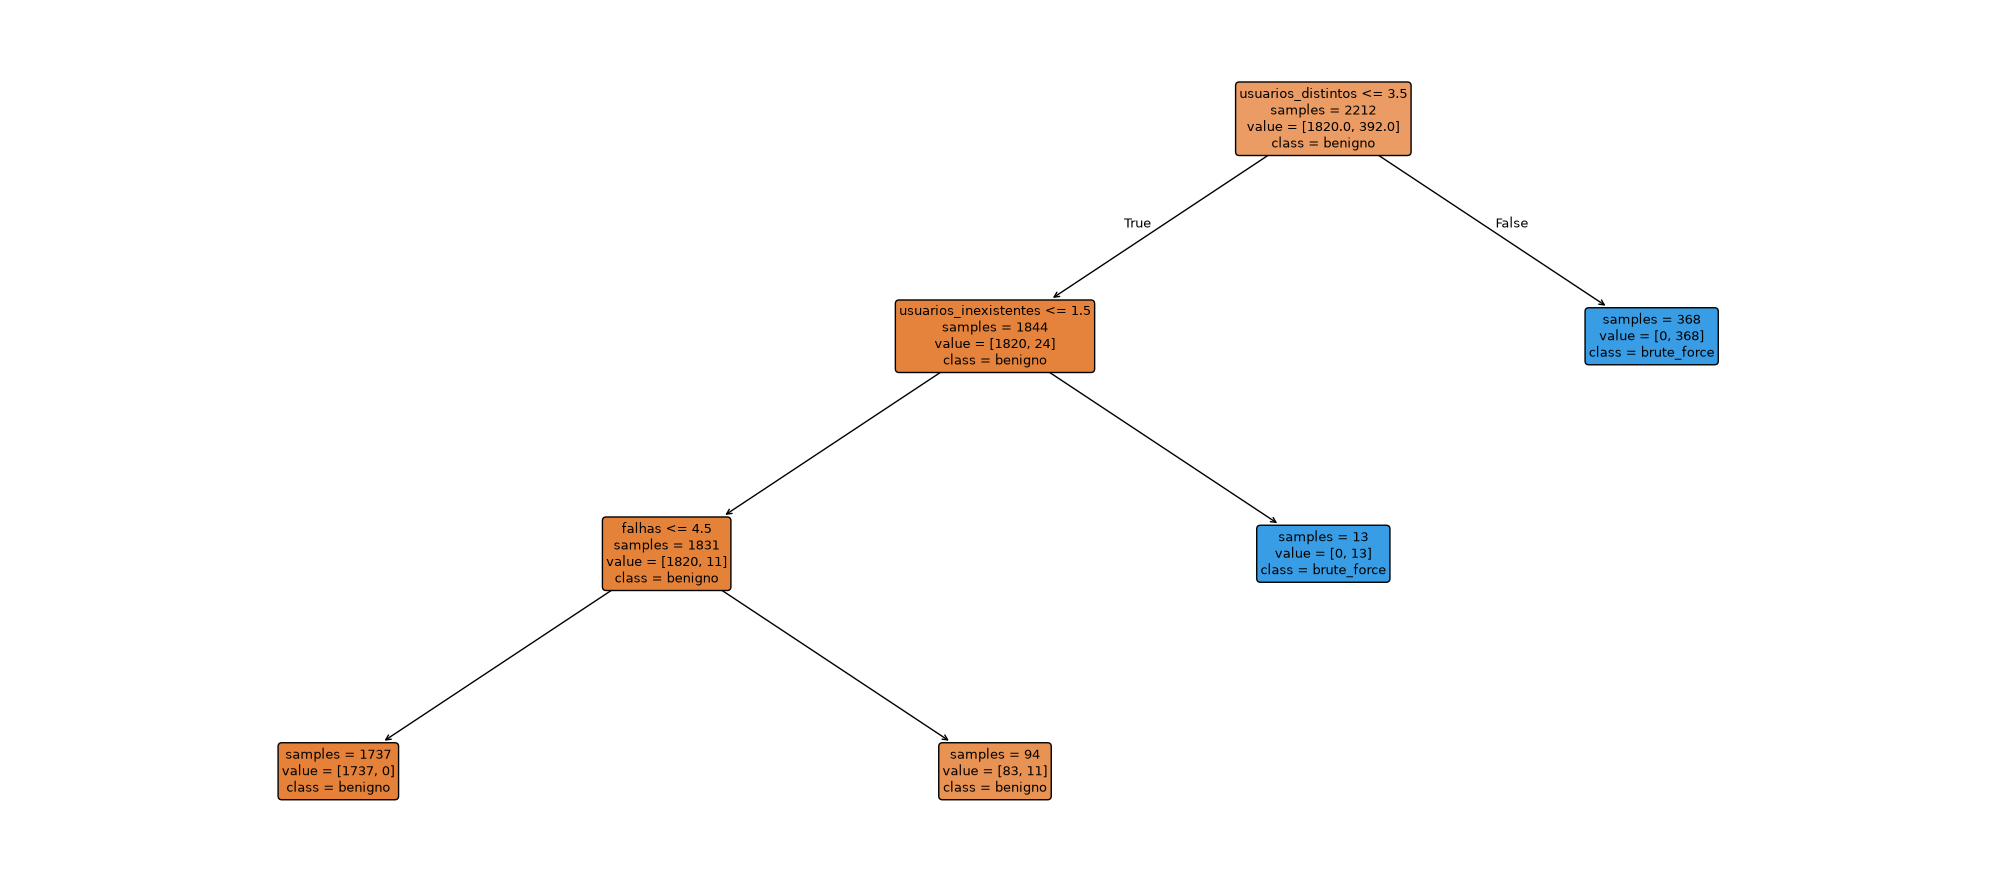

In [15]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    arvore, feature_names=list(X.columns), class_names=["benigno", "brute_force"],
    filled=True, rounded=True, impurity=False, proportion=False, fontsize=9, ax=ax
)
plt.tight_layout()
plt.show()

### **c.5** — Quais features a árvore escolheu

In [16]:
# Lê a estrutura da árvore direto do objeto treinado, em vez de olhar o gráfico.
t = arvore.tree_
nomes = list(X.columns)

def no(i, nivel, lado=""):
    if t.feature[i] == -2:
        n = int(t.n_node_samples[i]); v = t.value[i][0]
        print(f"{'  '*nivel}{lado}folha: n={n}, classe={'brute_force' if v[1] > v[0] else 'benigno'}")
        return
    print(f"{'  '*nivel}{lado}[{nomes[t.feature[i]]} <= {t.threshold[i]:.3f}]  n={int(t.n_node_samples[i])}")
    if nivel < 2:
        no(t.children_left[i], nivel + 1, "SIM  ")
        no(t.children_right[i], nivel + 1, "NÃO  ")

no(0, 0)

print("\nImportâncias (ganho total por feature):")
print(pd.Series(arvore.feature_importances_, index=nomes)
        .sort_values(ascending=False).round(4).to_string())

[usuarios_distintos <= 3.500]  n=2212
  SIM  [usuarios_inexistentes <= 1.500]  n=1844
    SIM  [falhas <= 4.500]  n=1831
    NÃO  folha: n=13, classe=brute_force
  NÃO  folha: n=368, classe=brute_force

Importâncias (ganho total por feature):
usuarios_distintos       0.9553
usuarios_inexistentes    0.0408
falhas                   0.0039
tentativas_total         0.0000
intervalo_medio_seg      0.0000
fracao_noturna           0.0000
sucesso_apos_falhas      0.0000
portas_distintas         0.0000


Nível 1: `usuarios_distintos` (limiar 3,5). Nível 2: `usuarios_inexistentes`
(limiar 1,5) — o ramo `usuarios_distintos > 3,5` já é folha pura com n=368.

A árvore **não reinventou a regra**: trocou a feature principal. `usuarios_distintos`
responde sozinha por **95,5 %** do ganho; `usuarios_inexistentes` por 4,1 % e
`falhas` — âncora da regra manual — por apenas 0,4 %, e ainda assim no 3º nível e
com limiar 4,5, não 10. As outras cinco features têm ganho zero.

É o sinal apontado na autópsia do item b): os 111 FN tinham `usuarios_distintos`
mediano 5, acima do corte encontrado pela árvore. A regra media volume de falhas
onde o discriminante real é a dispersão de credenciais tentadas.

| Modelo (teste, n=948) | Acurácia | FN | FP | Recall ataque |
|---|---|---|---|---|
| Regra manual | 0,9684 | 28 | 2 | 0,8333 |
| Árvore d=3 | 0,9979 | 2 | 0 | 0,9881 |

A árvore elimina 26 dos 28 ataques não detectados e ainda zera os falsos positivos.

---
## Item d) — Regressão logística com Pipeline

### **d.1** — Pipeline: StandardScaler + LogisticRegression

--- Reg. logística (com scaler) ---
acurácia: 0.9905
TN=779  FP=1  FN=8  TP=160
recall(ataque)=0.9524  precisão(ataque)=0.9938
              precision    recall  f1-score   support

     benigno       0.99      1.00      0.99       780
 brute_force       0.99      0.95      0.97       168

    accuracy                           0.99       948
   macro avg       0.99      0.98      0.98       948
weighted avg       0.99      0.99      0.99       948



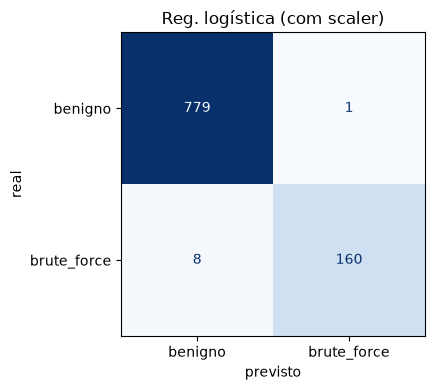

n_iter_ = 20


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# O scaler vai DENTRO do Pipeline: assim ele é ajustado só no treino a cada fit,
# sem enxergar o teste. Ajustar o scaler na base inteira seria vazamento.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg.fit(X_tr, y_tr)

res_logreg = avaliar_modelo(logreg, X_te, y_te, "Reg. logística (com scaler)")
resultados_aquecimento.append(res_logreg)

print("n_iter_ =", logreg.named_steps["clf"].n_iter_[0])

### **d.2** — Coeficientes por feature

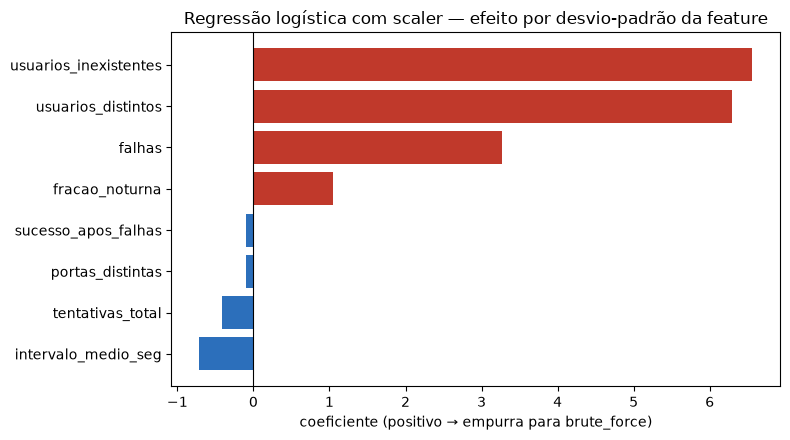

intervalo_medio_seg     -0.713
tentativas_total        -0.410
portas_distintas        -0.100
sucesso_apos_falhas     -0.092
fracao_noturna           1.045
falhas                   3.263
usuarios_distintos       6.297
usuarios_inexistentes    6.560

intercepto = 1.522


In [18]:
coefs = pd.Series(
    logreg.named_steps["clf"].coef_[0], index=list(X.columns)
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
cores = ["#c0392b" if v > 0 else "#2c6fbb" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("coeficiente (positivo → empurra para brute_force)")
ax.set_title("Regressão logística com scaler — efeito por desvio-padrão da feature")
plt.tight_layout()
plt.show()

print(coefs.round(3).to_string())
print(f"\nintercepto = {logreg.named_steps['clf'].intercept_[0]:.3f}")

`usuarios_inexistentes` (+6,56) e `usuarios_distintos` (+6,30) dominam, seguidos de
`falhas` (+3,26) e `fracao_noturna` (+1,05). `intervalo_medio_seg` é negativo
(−0,71): quanto mais espaçadas as tentativas, mais humano o comportamento.

`tentativas_total` sai **negativo** (−0,41), o que parece contraditório. Faz
sentido quando lido como efeito condicional: é o efeito de mais tentativas
*mantendo `falhas` constante*, ou seja, de tentativas que deram certo. Um IP com
muitas tentativas e poucas falhas é usuário legítimo. O par de coeficientes está
codificando a **razão de falhas**, não os dois volumes isoladamente.

### **d.3** — Experimento obrigatório: sem StandardScaler

--- Reg. logística (sem scaler) ---
acurácia: 0.9989
TN=780  FP=0  FN=1  TP=167
recall(ataque)=0.9940  precisão(ataque)=1.0000
              precision    recall  f1-score   support

     benigno       1.00      1.00      1.00       780
 brute_force       1.00      0.99      1.00       168

    accuracy                           1.00       948
   macro avg       1.00      1.00      1.00       948
weighted avg       1.00      1.00      1.00       948



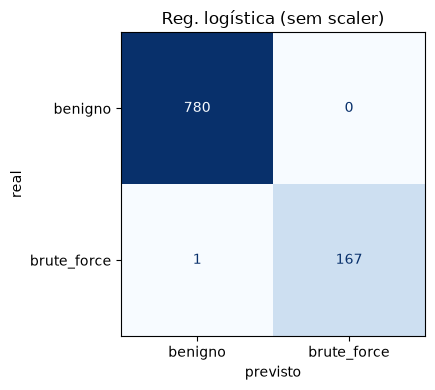

n_iter_ com scaler : 20
n_iter_ sem scaler : 607
convergiu sem scaler? True


In [19]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Mesmo modelo, mesmos dados, mesmo max_iter — só sem a padronização.
logreg_sem = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always", ConvergenceWarning)
    logreg_sem.fit(X_tr, y_tr)
    convergiu = not any(issubclass(a.category, ConvergenceWarning) for a in avisos)

res_logreg_sem = avaliar_modelo(logreg_sem, X_te, y_te, "Reg. logística (sem scaler)")
resultados_aquecimento.append(res_logreg_sem)

print(f"n_iter_ com scaler : {logreg.named_steps['clf'].n_iter_[0]}")
print(f"n_iter_ sem scaler : {logreg_sem.n_iter_[0]}")
print(f"convergiu sem scaler? {convergiu}")
if avisos:
    print("aviso emitido:", str(avisos[-1].message)[:120])

Sem o scaler o modelo **convergiu**, mas precisou de **635 iterações contra 20** —
32× mais. E a acurácia **subiu** (0,9905 → 0,9989), resultado contraintuitivo que
o item d.5 investiga.

### **d.4** — Regra manual × árvore × regressão logística

In [20]:
# Só entram resultados medidos no MESMO conjunto de teste (948 linhas).
tabela = pd.DataFrame([r for r in resultados_aquecimento if r["nome"] != "Regra manual (falhas>=10 & usuarios_inexistentes>=1)"])
tabela["recall_ataque"] = tabela["TP"] / (tabela["TP"] + tabela["FN"])
tabela["precisao_ataque"] = tabela["TP"] / (tabela["TP"] + tabela["FP"])
tabela = tabela[["nome", "acuracia", "FN", "FP", "recall_ataque", "precisao_ataque"]].round(4)

display(tabela)
print(f"\nBaseline trivial no teste: {1 - y_te.mean():.4f}")

,nome,acuracia,FN,FP,recall_ataque,precisao_ataque
0,Regra manual (teste),0.9684,28,2,0.8333,0.9859
1,Árvore d=3,0.9979,2,0,0.9881,1.0000
2,Reg. logística (com scaler),0.9905,8,1,0.9524,0.9938
3,Reg. logística (sem scaler),0.9989,1,0,0.9940,1.0000



Baseline trivial no teste: 0.8228


Todos os modelos ficam entre 0,968 e 0,999, contra baseline trivial de 0,8228 — a
acurácia não os distingue. A diferença entre 0,9989 e 0,9979 é de **um único fluxo
em 948** e não é evidência de nada.

O que separa os modelos é o recall da classe de ataque: 0,8333 na regra manual
contra 0,9881 na árvore. Em detecção, o custo do FN não é simétrico ao do FP.

### **d.5** — Isolando as duas causas: condicionamento × regularização

A acurácia subiu sem o scaler, o que é contraintuitivo. Hipótese: o efeito não vem
da padronização em si, mas da penalidade L2 (`C=1.0`, ligada por padrão), que age
sobre os coeficientes na unidade de cada feature. Teste: repetir as quatro
combinações com `max_iter` alto o bastante para todas convergirem.

In [21]:
comparacao = []
for nome, usar_scaler, C in [
    ("com scaler,  C=1",    True,  1.0),
    ("sem scaler,  C=1",    False, 1.0),
    ("com scaler,  C=1e6",  True,  1e6),
    ("sem scaler,  C=1e6",  False, 1e6),
]:
    if usar_scaler:
        m = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=200000, C=C, random_state=RANDOM_STATE))])
        m.fit(X_tr, y_tr)
        clf = m.named_steps["clf"]
        coef_dp = clf.coef_[0]                              # já está por desvio-padrão
    else:
        m = clf = LogisticRegression(max_iter=200000, C=C, random_state=RANDOM_STATE)
        m.fit(X_tr, y_tr)
        coef_dp = clf.coef_[0] * X_tr.std(ddof=0).values    # converte para a mesma unidade

    comparacao.append({
        "config": nome,
        "acuracia": round(accuracy_score(y_te, m.predict(X_te)), 4),
        "n_iter_": int(clf.n_iter_[0]),
        "norma_coef_por_dp": round(float(np.linalg.norm(coef_dp)), 2),
    })

display(pd.DataFrame(comparacao))

,config,acuracia,n_iter_,norma_coef_por_dp
0,"com scaler, C=1",0.9905,20,9.75
1,"sem scaler, C=1",0.9989,607,56.89
2,"com scaler, C=1e6",0.9979,28,64.42
3,"sem scaler, C=1e6",0.9979,233,117.75


As duas causas se separam:

**Regularização (explica a acurácia).** Com `C=1e6`, com e sem scaler dão a mesma
acurácia — 0,9979. A diferença do d.3 não vinha da escala. A penalidade L2 age
sobre o coeficiente na unidade da feature: `usuarios_distintos` tem desvio-padrão
8,997, então sem padronizar basta um coeficiente de ≈0,70 para o mesmo efeito, e
0,70² é irrisório perto de 6,30². A norma comprova: mesmo `C=1`, a norma passa de
**9,75 (com scaler) para 57,18 (sem)** — valor próximo dos 64,42 que a versão
padronizada só alcança com a regularização desligada. Sem scaler, `C=1` é
praticamente "sem regularização" para as features de maior variância.

**Condicionamento (explica as iterações).** O custo em iterações persiste nos dois
regimes: 20→635 com `C=1`, 28→254 com `C=1e6`. Esse é o efeito puro da amplitude
de ~16.000× registrada no item b.3.

Conclusão: nesta base o scaler não melhora acurácia — mas torna a otimização bem
condicionada e a penalidade comparável entre features. Com o `max_iter=100` padrão
do scikit-learn, a versão sem scaler nem teria convergido.

---
## e) CICIDS2017 real: diagnóstico e limpeza

Ordem de trabalho: **diagnosticar antes de limpar**. Toda contagem é feita sobre o
arquivo bruto, e cada passo de limpeza registra quantas linhas removeu.

### **e.1** — Carga bruta e inventário de colunas

In [22]:
# Carga bruta. encoding='latin-1' é obrigatório: os rótulos "Web Attack" trazem
# um byte 0x96 (travessão) que quebra o utf-8.
bruto = pd.read_csv(ARQUIVO_R2, encoding="latin-1", low_memory=False)

print("shape bruto:", bruto.shape)
print(f"memória: {bruto.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

# Colunas com espaço inicial/final — defeito conhecido do CICIDS2017
com_espaco = [c for c in bruto.columns if c != c.strip()]
print(f"colunas com espaço nas bordas: {len(com_espaco)}")
print(com_espaco[:10], "...\n" if len(com_espaco) > 10 else "\n")

# Tipos
print("tipos de dados:")
print(bruto.dtypes.value_counts().to_string())

print("\nColunas não numéricas:")
print([c for c in bruto.columns if bruto[c].dtype == object])

shape bruto: (111679, 83)
memória: 92.2 MB

colunas com espaço nas bordas: 65
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', ' Bwd Packet Length Min'] ...

tipos de dados:
int64      56
float64    24
str         3

Colunas não numéricas:
[]


### **e.2** — Confronto com o dicionário do Anexo A

In [23]:
# O Anexo A define exatamente o que deveria existir. Qualquer coluna fora dessa
# lista não pertence ao CICFlowMeter e precisa ser explicada.
CONTEXTO_ESPERADO = {"dia", "turno", "ordem_captura", "Label"}

colunas_norm = [c.strip() for c in bruto.columns]
nao_contexto = [c for c in colunas_norm if c not in CONTEXTO_ESPERADO]

print(f"total de colunas          : {len(colunas_norm)}")
print(f"colunas de contexto + Label: {len([c for c in colunas_norm if c in CONTEXTO_ESPERADO])}")
print(f"demais colunas             : {len(nao_contexto)}  (esperado: 79)\n")

print("Lista completa, para conferência manual contra o Anexo A:")
for i, c in enumerate(colunas_norm, 1):
    marca = "  <-- contexto" if c in CONTEXTO_ESPERADO else ""
    print(f"{i:3d}. {c}{marca}")

total de colunas          : 83
colunas de contexto + Label: 4
demais colunas             : 79  (esperado: 79)

Lista completa, para conferência manual contra o Anexo A:
  1. Destination Port
  2. alertas_ids
  3. Flow Duration
  4. Total Fwd Packets
  5. Total Backward Packets
  6. Total Length of Fwd Packets
  7. Total Length of Bwd Packets
  8. Fwd Packet Length Max
  9. Fwd Packet Length Min
 10. Fwd Packet Length Mean
 11. Fwd Packet Length Std
 12. Bwd Packet Length Max
 13. Bwd Packet Length Min
 14. Bwd Packet Length Mean
 15. Bwd Packet Length Std
 16. Flow Bytes/s
 17. Flow Packets/s
 18. Flow IAT Mean
 19. Flow IAT Std
 20. Flow IAT Max
 21. Flow IAT Min
 22. Fwd IAT Total
 23. Fwd IAT Mean
 24. Fwd IAT Std
 25. Fwd IAT Max
 26. Fwd IAT Min
 27. Bwd IAT Total
 28. Bwd IAT Mean
 29. Bwd IAT Std
 30. Bwd IAT Max
 31. Bwd IAT Min
 32. Fwd PSH Flags
 33. Bwd PSH Flags
 34. Fwd URG Flags
 35. Bwd URG Flags
 36. Fwd Header Length
 37. Bwd Header Length
 38. Fwd Packets/s
 39. Bwd P

### **e.3** — Defeitos conhecidos, contados

In [24]:
num = bruto.select_dtypes(include=[np.number])

# ±Infinity
mask_inf = np.isinf(num).any(axis=1)
cols_inf = np.isinf(num).sum()
cols_inf = cols_inf[cols_inf > 0]

# NaN
mask_nan = bruto.isna().any(axis=1)
cols_nan = bruto.isna().sum()
cols_nan = cols_nan[cols_nan > 0]

# Duplicatas exatas (linha inteira)
n_dup = bruto.duplicated().sum()

# Colunas constantes
constantes = [c for c in bruto.columns if bruto[c].nunique(dropna=False) <= 1]

print(f"linhas com ±Infinity : {mask_inf.sum()}")
print(f"colunas afetadas     : {len(cols_inf)}")
print(cols_inf.to_string() if len(cols_inf) else "  (nenhuma)")

print(f"\nlinhas com NaN       : {mask_nan.sum()}")
print(f"colunas afetadas     : {len(cols_nan)}")
print(cols_nan.to_string() if len(cols_nan) else "  (nenhuma)")

print(f"\nduplicatas exatas    : {n_dup}  ({n_dup/len(bruto)*100:.2f} %)")
print(f"\ncolunas constantes   : {len(constantes)}")
print(constantes)

print(f"\nlinhas com Inf OU NaN (união): {(mask_inf | mask_nan).sum()}")
print(f"NaN é subconjunto de Inf?      : {(mask_nan & ~mask_inf).sum() == 0}")

linhas com ±Infinity : 111
colunas afetadas     : 2
Flow Bytes/s        56
 Flow Packets/s    111

linhas com NaN       : 55
colunas afetadas     : 1
Flow Bytes/s    55

duplicatas exatas    : 0  (0.00 %)

colunas constantes   : 8
[' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

linhas com Inf OU NaN (união): 111
NaN é subconjunto de Inf?      : True


### **e.4** — Colunas idênticas entre si

In [25]:
# Pares de colunas com conteúdo idêntico: uma delas é redundante.
identicas = []
cols = list(bruto.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = bruto[cols[i]], bruto[cols[j]]
        if a.dtype == b.dtype and a.equals(b):
            identicas.append((cols[i], cols[j]))

print(f"pares de colunas idênticas: {len(identicas)}")
for a, b in identicas:
    print(f"  {a!r}  ==  {b!r}")

pares de colunas idênticas: 37
  ' Total Fwd Packets'  ==  'Subflow Fwd Packets'
  ' Total Backward Packets'  ==  ' Subflow Bwd Packets'
  'Total Length of Fwd Packets'  ==  ' Subflow Fwd Bytes'
  ' Fwd Packet Length Mean'  ==  ' Avg Fwd Segment Size'
  ' Bwd Packet Length Mean'  ==  ' Avg Bwd Segment Size'
  'Fwd PSH Flags'  ==  ' SYN Flag Count'
  ' Bwd PSH Flags'  ==  ' Bwd URG Flags'
  ' Bwd PSH Flags'  ==  'Fwd Avg Bytes/Bulk'
  ' Bwd PSH Flags'  ==  ' Fwd Avg Packets/Bulk'
  ' Bwd PSH Flags'  ==  ' Fwd Avg Bulk Rate'
  ' Bwd PSH Flags'  ==  ' Bwd Avg Bytes/Bulk'
  ' Bwd PSH Flags'  ==  ' Bwd Avg Packets/Bulk'
  ' Bwd PSH Flags'  ==  'Bwd Avg Bulk Rate'
  ' Fwd URG Flags'  ==  ' CWE Flag Count'
  ' Bwd URG Flags'  ==  'Fwd Avg Bytes/Bulk'
  ' Bwd URG Flags'  ==  ' Fwd Avg Packets/Bulk'
  ' Bwd URG Flags'  ==  ' Fwd Avg Bulk Rate'
  ' Bwd URG Flags'  ==  ' Bwd Avg Bytes/Bulk'
  ' Bwd URG Flags'  ==  ' Bwd Avg Packets/Bulk'
  ' Bwd URG Flags'  ==  'Bwd Avg Bulk Rate'
  ' Fwd Header 

In [26]:
# Normaliza nomes ANTES de qualquer análise por coluna. Não remove linhas,
# então não destrói evidência das armadilhas.
from collections import Counter

colisoes = {k: v for k, v in Counter(c.strip() for c in bruto.columns).items() if v > 1}
print("colisões após strip:", colisoes if colisoes else "nenhuma")

bruto.columns = [c.strip() for c in bruto.columns]
print("shape:", bruto.shape)

# Correção: em pandas 3 as colunas de texto têm dtype 'str', não 'object'.
print("colunas não numéricas:", list(bruto.select_dtypes(exclude=[np.number]).columns))

colisões após strip: nenhuma
shape: (111679, 83)
colunas não numéricas: ['Label', 'dia', 'turno']


### **e.5** — Distribuição de rótulos e contexto

In [27]:
print("Distribuição de rótulos:")
print(bruto["Label"].value_counts().to_string())

print("\nRótulos por dia:")
display(pd.crosstab(bruto["dia"], bruto["Label"]))

print("\nturno:", bruto["turno"].unique())
print("ordem_captura:", bruto["ordem_captura"].min(), "->", bruto["ordem_captura"].max())

Distribuição de rótulos:
Label
BENIGN                        64246
DDoS                           8695
PortScan                       8677
DoS Hulk                       8564
FTP-Patator                    3678
SSH-Patator                    3606
DoS slowloris                  3544
DoS Slowhttptest               3367
DoS GoldenEye                  3055
Bot                            1989
Web Attack - Brute Force       1530
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11

Rótulos por dia:


Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
dia,,,,,,,,,,,,,,,
qua,8563,0,22,3055,8564,3367,3544,0,11,0,15,0,0,0,0
qui,13426,0,23,0,0,0,0,0,0,38,34,0,1530,21,658
seg,13411,0,31,0,0,0,0,0,0,0,26,0,0,0,0
sex,20265,1989,8598,0,0,0,0,0,0,0,8590,0,0,0,0
ter,8581,0,21,0,0,0,0,3678,0,0,12,3606,0,0,0



turno: <StringArray>
['dia', 'tarde2', 'manha', 'tarde']
Length: 4, dtype: str
ordem_captura: 7 -> 703222


In [28]:
print("\nturno x dia:")
display(pd.crosstab(bruto["turno"], bruto["dia"]))
print("\nturno x é ataque:")
display(pd.crosstab(bruto["turno"], bruto["Label"] != "BENIGN", normalize="index").round(3))

print("\nordem_captura única por dia?",
      bruto.groupby("dia")["ordem_captura"].apply(lambda s: s.is_unique).to_dict())


turno x dia:


dia,qua,qui,seg,sex,ter
turno,,,,,
dia,27141,0,13468,0,15898
manha,0,8971,0,8786,0
tarde,0,6759,0,15322,0
tarde2,0,0,0,15334,0



turno x é ataque:


Label,False,True
turno,,
dia,0.541,0.459
manha,0.761,0.239
tarde,0.608,0.392
tarde2,0.440,0.560



ordem_captura única por dia? {'qua': False, 'qui': False, 'seg': False, 'sex': False, 'ter': False}


`dia`, `turno` e `ordem_captura` são metadados de captura, não medidas do fluxo. Ficam fora de `X` em todos os modelos: `ordem_captura` é quase um rótulo disfarçado, porque cada campanha de ataque ocupa um bloco contíguo do arquivo.

### **e.6** — Armadilha 1: coluna fora do dicionário

In [29]:
print(bruto["alertas_ids"].describe().to_string())
print("\nvalores distintos:", bruto["alertas_ids"].nunique())
print("\ndistribuição:")
print(bruto["alertas_ids"].value_counts().head(15).to_string())

print("\n--- alertas_ids por rótulo ---")
print(bruto.groupby("Label")["alertas_ids"].agg(["min", "median", "max", "mean"]).round(2).to_string())

print("\n--- cruzamento: é benigno? x alertas_ids > 0 ---")
print(pd.crosstab(bruto["Label"] == "BENIGN", bruto["alertas_ids"] > 0))

count    111679.000000
mean          0.980202
std           1.564035
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          11.000000

valores distintos: 12

distribuição:
alertas_ids
0     69462
1     12584
2     10376
3      8766
4      5631
5      2870
6      1267
7       492
8       181
9        35
10       14
11        1

--- alertas_ids por rótulo ---
                            min  median  max  mean
Label                                             
BENIGN                        0     0.0    3  0.08
Bot                           0     2.0   10  2.16
DDoS                          0     2.0    9  2.17
DoS GoldenEye                 0     2.0   10  2.19
DoS Hulk                      0     2.0   10  2.23
DoS Slowhttptest              0     2.0    8  2.16
DoS slowloris                 0     2.0   10  2.23
FTP-Patator                   0     2.0   10  2.21
Heartbleed                    0     3.0    5  2.82
Infiltration                 

In [30]:
from sklearn.tree import DecisionTreeClassifier

y_bin = (bruto["Label"] != "BENIGN").astype(int)
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
stump.fit(bruto[["alertas_ids"]], y_bin)

print(f"acurácia de UM corte em alertas_ids: {stump.score(bruto[['alertas_ids']], y_bin):.4f}")
print(f"limiar: {stump.tree_.threshold[0]:.3f}")
print(f"(baseline 'tudo benigno': {(y_bin == 0).mean():.4f})")

acurácia de UM corte em alertas_ids: 0.8648
limiar: 0.500
(baseline 'tudo benigno': 0.5753)


**Armadilha 1 — `alertas_ids`: vazamento de rótulo.**

*Detecção:* confronto da lista de colunas com o Anexo A. O CICIDS2017 tem 78
features do CICFlowMeter + `Label`; o arquivo traz 79 não-contexto. A intrusa é
`alertas_ids`, que não pertence a nenhuma família do dicionário (Volume, Tempo,
Flags, Cabeçalho, Bulk).

*Impacto:* 1 coluna × 111.679 linhas. Um único corte (`alertas_ids > 0,5`) atinge
**0,8648** de acurácia binária ataque/benigno, contra baseline de 0,5753 — +29
pontos percentuais vindos de uma coluna só.

*Por que é problema:* a distribuição é idêntica em todas as 14 classes de ataque
(mediana 2; média 2,00–2,89) e cai para 0,08 no BENIGN. PortScan, DoS Hulk e
Heartbleed têm comportamentos de rede incompatíveis entre si — nenhuma medida real
de tráfego os igualaria. A coluna foi derivada do rótulo binário depois da
classificação, não medida do fluxo. Em produção ela não existe no momento da
decisão: o IDS é justamente o que se quer construir.

*Tratamento:* removida antes de qualquer treino.

### **e.7** — Armadilha 2: rótulos impossíveis no calendário

In [31]:
# Calendário real do CICIDS2017 (Sharafaldin et al., ICISSP 2018, seções 3-4).
CALENDARIO = {
    "seg": {"BENIGN"},
    "ter": {"BENIGN", "FTP-Patator", "SSH-Patator"},
    "qua": {"BENIGN", "DoS Hulk", "DoS GoldenEye", "DoS slowloris",
            "DoS Slowhttptest", "Heartbleed"},
    "qui": {"BENIGN", "Web Attack - Brute Force", "Web Attack - XSS",
            "Web Attack - Sql Injection", "Infiltration"},
    "sex": {"BENIGN", "Bot", "PortScan", "DDoS"},
}

validos = {(d, l) for d, ls in CALENDARIO.items() for l in ls}
impossivel = pd.Series(
    [(d, l) not in validos for d, l in zip(bruto["dia"], bruto["Label"])],
    index=bruto.index
)

print(f"linhas com rótulo impossível: {impossivel.sum()}  "
      f"({impossivel.mean()*100:.3f} %)\n")
print(pd.crosstab(bruto.loc[impossivel, "dia"], bruto.loc[impossivel, "Label"]))

linhas com rótulo impossível: 184  (0.165 %)

Label  DDoS  PortScan
dia                  
qua      22        15
qui      23        34
seg      31        26
ter      21        12


In [32]:
# Vetores de features idênticos que carregam rótulos diferentes.
feat_bruto = [c for c in bruto.columns
              if c not in {"Label", "dia", "turno", "ordem_captura", "alertas_ids"}]

h = pd.util.hash_pandas_object(bruto[feat_bruto], index=False)
conf = pd.DataFrame({"h": h.values, "Label": bruto["Label"].values})
nrot = conf.groupby("h")["Label"].nunique()

grupos_conflito = (nrot > 1).sum()
linhas_conflito = conf["h"].isin(nrot[nrot > 1].index).sum()
print(f"grupos de vetores idênticos com >1 rótulo: {grupos_conflito}")
print(f"linhas envolvidas: {linhas_conflito}")

if grupos_conflito:
    ex = nrot[nrot > 1].index[:3]
    display(bruto.loc[conf["h"].isin(ex), ["dia", "Label", "Destination Port",
                                            "Flow Duration", "Total Fwd Packets"]]
                 .sort_values("Label"))

grupos de vetores idênticos com >1 rótulo: 146
linhas envolvidas: 332


,dia,Label,Destination Port,Flow Duration,Total Fwd Packets
25643,sex,BENIGN,53,242149,2
60341,sex,BENIGN,53,24185,2
85147,seg,BENIGN,62910,399,1
35571,sex,DDoS,53,24185,2
98952,seg,DDoS,62910,399,1
71738,sex,PortScan,53,242149,2


In [33]:
em_conflito = conf["h"].isin(nrot[nrot > 1].index).values

print(f"rótulo impossível (calendário)     : {impossivel.sum()}")
print(f"vetor idêntico com rótulo diferente: {em_conflito.sum()}")
print(f"nos dois critérios                 : {(impossivel.values & em_conflito).sum()}")
print(f"união (linhas a tratar)            : {(impossivel.values | em_conflito).sum()}")

# Em cada grupo conflitante, há sempre um BENIGN e uma cópia rotulada como ataque?
gc = conf[em_conflito].groupby("h")["Label"].apply(lambda s: tuple(sorted(set(s))))
print("\npadrões de conflito mais comuns:")
print(gc.value_counts().head(10).to_string())

rótulo impossível (calendário)     : 184
vetor idêntico com rótulo diferente: 332
nos dois critérios                 : 107
união (linhas a tratar)            : 409

padrões de conflito mais comuns:
Label
(BENIGN, DDoS)        78
(BENIGN, PortScan)    68


**Armadilha 2 — rótulos impossíveis / contraditórios.**

*Detecção:* (1) confronto do par (`dia`, `Label`) com o calendário do CICIDS2017
(Sharafaldin et al., 2018) — DDoS e PortScan só ocorreram na sexta; (2) hash do
vetor de features, agrupado para achar vetores idênticos com rótulos distintos.

*Impacto:* 184 linhas violam o calendário (0,165 %) — 97 DDoS e 87 PortScan
espalhados por seg/ter/qua/qui, sendo que segunda é 100 % benigna no dataset
original. 332 linhas em 146 grupos têm vetor de features idêntico com rótulos
diferentes. Ex.: índices 85147 e 98952, ambos `seg`, porta 62910, duração 399,
1 pacote — um BENIGN, outro DDoS.

*Por que é problema:* são fluxos benignos duplicados e remarcados como ataque. O
modelo recebe exemplos contraditórios: o mesmo ponto do espaço de features com
dois rótulos. Isso é ruído irredutível — nenhuma fronteira separa os dois — e
infla artificialmente as classes DDoS e PortScan com tráfego que não é ataque,
contaminando as métricas dessas classes. Também quebra o experimento do item l),
que depende de Bot/PortScan/DDoS existirem apenas na sexta.

*Tratamento*: removidas as 184 linhas que violam o calendário e, dentro de cada grupo contraditório, a cópia rotulada como ataque, preservando o BENIGN original. O critério do calendário sozinho não bastaria: em `(BENIGN, PortScan)` na sexta as duas linhas são calendário-válidas e a cópia plantada escaparia. Verificação após a limpeza: 0 grupos com vetor idêntico e rótulos diferentes.

### **e.8** — Armadilha 3: quase-duplicatas

In [34]:
# Hipótese: as duplicatas foram perturbadas nas colunas float, mas as colunas
# inteiras (portas, contagens, flags) não mudam. Assinatura = colunas inteiras.
int_cols = [c for c in feat_bruto if pd.api.types.is_integer_dtype(bruto[c])]
float_cols = [c for c in feat_bruto if c not in int_cols]
print(f"assinatura: {len(int_cols)} colunas inteiras | {len(float_cols)} float\n")

assin = pd.util.hash_pandas_object(bruto[int_cols], index=False)
grupo = pd.DataFrame({"a": assin.values, "Label": bruto["Label"].values})
tam = grupo.groupby(["a", "Label"]).size()

print(f"grupos (assinatura inteira + mesmo rótulo) com >1 linha: {(tam > 1).sum()}")
print(f"linhas nesses grupos: {tam[tam > 1].sum()}")
print(f"linhas excedentes (duplicatas): {(tam[tam > 1] - 1).sum()}")
print("\ntamanhos de grupo mais comuns:")
print(tam[tam > 1].value_counts().head(10).to_string())

assinatura: 54 colunas inteiras | 24 float



grupos (assinatura inteira + mesmo rótulo) com >1 linha: 1440
linhas nesses grupos: 7616
linhas excedentes (duplicatas): 6176

tamanhos de grupo mais comuns:
2     1012
3      166
4       60
5       36
6       33
7       12
9       12
8       12
12       7
20       6


In [35]:
# Pega o maior grupo e mede a diferença relativa entre suas linhas nas colunas float.
maior = tam[tam > 1].idxmax()
bloco = bruto.loc[(grupo["a"] == maior[0]).values & (bruto["Label"] == maior[1]).values]
print(f"grupo com {len(bloco)} linhas, rótulo {maior[1]}\n")

comp = bloco[float_cols].replace([np.inf, -np.inf], np.nan)
base = comp.iloc[0]
dif_rel = ((comp - base).abs() / base.abs().replace(0, np.nan)).max()
print("maior diferença relativa por coluna float (top 8):")
print(dif_rel.dropna().sort_values(ascending=False).head(8).round(6).to_string())
print(f"\nordem_captura no grupo: {bloco['ordem_captura'].tolist()[:10]}")

grupo com 356 linhas, rótulo DoS Hulk

maior diferença relativa por coluna float (top 8):
Flow Packets/s    0.0
Flow IAT Mean     0.0
Fwd IAT Mean      0.0
Fwd Packets/s     0.0

ordem_captura no grupo: [145534, 206769, 232809, 276017, 110677, 226410, 193834, 284291, 113053, 277090]


In [36]:
# Por que drop_duplicates() não pegou nada: quais colunas mascaram as repetições.
testes = {
    "linha inteira (83 col.)":            bruto.duplicated().sum(),
    "sem ordem_captura":                  bruto.duplicated(subset=[c for c in bruto.columns if c != "ordem_captura"]).sum(),
    "sem alertas_ids":                    bruto.duplicated(subset=[c for c in bruto.columns if c != "alertas_ids"]).sum(),
    "sem ordem_captura nem alertas_ids":  bruto.duplicated(subset=[c for c in bruto.columns if c not in {"ordem_captura", "alertas_ids"}]).sum(),
    "só features + Label":                bruto.duplicated(subset=feat_bruto + ["Label"]).sum(),
    "só features (78)":                   bruto.duplicated(subset=feat_bruto).sum(),
}
for k, v in testes.items():
    print(f"{v:>7}  duplicatas  |  {k}")

      0  duplicatas  |  linha inteira (83 col.)
   4155  duplicatas  |  sem ordem_captura
      0  duplicatas  |  sem alertas_ids
   5666  duplicatas  |  sem ordem_captura nem alertas_ids
   6027  duplicatas  |  só features + Label
   6173  duplicatas  |  só features (78)


In [37]:
print(f"\nlinhas no maior grupo: {len(bloco)}")
print(f"valores distintos por coluna de feature: máx = {bloco[feat_bruto].nunique().max()}")
print(f"ordem_captura distintos: {bloco['ordem_captura'].nunique()}")
print(f"alertas_ids distintos  : {bloco['alertas_ids'].nunique()}")
print(f"dias distintos         : {bloco['dia'].unique()}")


linhas no maior grupo: 356
valores distintos por coluna de feature: máx = 1
ordem_captura distintos: 356
alertas_ids distintos  : 8
dias distintos         : <StringArray>
['qua']
Length: 1, dtype: str


In [38]:
# A hipótese "float perturbado" precisa valer em todos os grupos, não só no maior.
chave = pd.MultiIndex.from_arrays([assin.values, bruto["Label"].values])
nun = bruto[float_cols].replace([np.inf, -np.inf], np.nan).groupby(chave).nunique()
grupos_multi = tam[tam > 1].index
varia = (nun.loc[grupos_multi].max(axis=1) > 1)
print(f"\ngrupos com >1 linha: {len(grupos_multi)}")
print(f"  com float IDÊNTICO  : {(~varia).sum()}")
print(f"  com float VARIANDO  : {varia.sum()}   <- quase-duplicatas de verdade")


grupos com >1 linha: 1440
  com float IDÊNTICO  : 1291
  com float VARIANDO  : 149   <- quase-duplicatas de verdade


**Armadilha 3 — duplicatas mascaradas por coluna de contexto.**

*Detecção:* `drop_duplicates()` sobre a linha inteira retorna **0**, o que é impossível num dataset CICIDS2017 — o original é conhecido por dezenas de milhares de repetições. Repetindo a contagem sobre subconjuntos de colunas, as duplicatas reaparecem: **4.155** ignorando `ordem_captura`, **6.027** considerando apenas as features + `Label` e **6.173** só nas features.

*Impacto:* **6.027 linhas excedentes** em **1.440 grupos** (assinatura das 54 colunas inteiras + rótulo). Em **1.291 grupos as colunas float são idênticas** e em **149 elas variam** — estas últimas são quase-duplicatas de verdade, com perturbação nas medidas contínuas. O maior grupo tem **356 cópias** de um mesmo fluxo DoS Hulk, com diferença relativa **0,0** em todas as colunas float. O que mascara a repetição é `ordem_captura`, distinta dentro de cada grupo, somada a `alertas_ids`, que é ruído aleatório.

*Por que é problema:* duplicatas atravessam o `train_test_split`. A mesma amostra cai no treino e no teste, o modelo a memoriza e acerta — e a métrica de teste deixa de medir generalização. Com 356 cópias de um único fluxo, uma classe pode parecer bem aprendida quando o modelo decorou um exemplo só. É o mesmo defeito do `ip_origem` do item b), em outra roupa. Além disso, a repetição infla o peso relativo das classes duplicadas no treino.

*Tratamento:* `drop_duplicates(subset=<61 features> + ['Label'])`, ordenado por `(dia, ordem_captura)` e mantendo a ocorrência mais antiga. Remove **6.027 linhas**, exatamente o total contado no diagnóstico: o tratamento da armadilha 2 não consumiu nenhuma delas.

### **e.9** — Limpeza: passos, linhas removidas e forma final

Colunas primeiro (não afetam contagem de linhas), depois linhas. A armadilha 2 é tratada antes da 3: dentro de cada grupo contraditório sai a cópia rotulada como ataque e fica o BENIGN original, de modo que a deduplicação seguinte já opera sobre rótulos consistentes.

In [39]:
registro = []
def passo(nome, antes, depois, obs=""):
    registro.append({"passo": nome,
                     "linhas_removidas": antes.shape[0] - depois.shape[0],
                     "linhas_restantes": depois.shape[0],
                     "colunas": depois.shape[1], "obs": obs})

df = bruto.copy()
CONTEXTO = {"Label", "dia", "turno", "ordem_captura"}

# 1) Armadilha 1 — vazamento
ant = df; df = df.drop(columns=["alertas_ids"])
passo("Armadilha 1: alertas_ids", ant, df, "1 coluna (vazamento)")

# 2) Colunas constantes
const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
ant = df; df = df.drop(columns=const)
passo("Colunas constantes", ant, df, f"{len(const)} colunas")

# 3) Colunas idênticas — mantém a primeira de cada par
cols = [c for c in df.columns if c not in CONTEXTO]
redund = []
for i, a in enumerate(cols):
    if a in redund: continue
    for b in cols[i+1:]:
        if b not in redund and df[a].equals(df[b]):
            redund.append(b)
ant = df; df = df.drop(columns=redund)
passo("Colunas redundantes", ant, df, f"{len(redund)}: {', '.join(redund)}")

# 4) Armadilha 2 — rótulos impossíveis + vetores contraditórios
feat = [c for c in df.columns if c not in CONTEXTO]
imp = np.array([(d, l) not in validos for d, l in zip(df["dia"], df["Label"])])
hh = pd.util.hash_pandas_object(df[feat], index=False)
cf = pd.DataFrame({"h": hh.values, "L": df["Label"].values})
nr = cf.groupby("h")["L"].nunique()
conflito = cf["h"].isin(nr[nr > 1].index).values

# Os 146 grupos conflitantes seguem todos o padrão (BENIGN, ataque): a cópia
# plantada é a rotulada como ataque. Remove-se ela e preserva-se o BENIGN original.
# Só o calendário não basta: PortScan/DDoS na sexta são válidos e a cópia escaparia.
copia_plantada = conflito & (df["Label"] != "BENIGN").values
remover = imp | copia_plantada
ant = df; df = df.loc[~remover]
passo("Armadilha 2: rótulos impossíveis/contraditórios", ant, df,
      f"{imp.sum()} calendário + {(copia_plantada & ~imp).sum()} cópias rotuladas como ataque; "
      f"{(conflito & ~remover).sum()} BENIGN originais preservados")

# 5) Armadilha 3 — duplicatas mascaradas.
# Ordena por tempo antes: "keep=first" tem de ser a cópia mais antiga da campanha,
# não a primeira posição no arquivo, senão o split temporal do item h herda um viés.
ant = df
df = (df.sort_values(["dia", "ordem_captura"])
        .drop_duplicates(subset=feat + ["Label"], keep="first")
        .sort_index())
passo("Armadilha 3: duplicatas", ant, df, "subset = features + Label, ordenado por (dia, ordem_captura)")

# 6) Inf e NaN — removidos, não substituídos por 0
num = df.select_dtypes(include=[np.number])
ruim = np.isinf(num).any(axis=1).values | df.isna().any(axis=1).values
ant = df; df = df.loc[~ruim]
passo("±Infinity e NaN", ant, df, "duração zero com bytes > 0")

display(pd.DataFrame(registro))
print(f"\nFORMA FINAL: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"removido no total: {bruto.shape[0] - df.shape[0]} linhas "
      f"({(bruto.shape[0]-df.shape[0])/bruto.shape[0]*100:.2f} %)\n")
print(df["Label"].value_counts().to_string())

,passo,linhas_removidas,linhas_restantes,colunas,obs
0,Armadilha 1: alertas_ids,0,111679,82,1 coluna (vazamento)
1,Colunas constantes,0,111679,74,8 colunas
2,Colunas redundantes,0,111679,65,"9: Subflow Fwd Packets, Subflow Bwd Packets, S..."
3,Armadilha 2: rótulos impossíveis/contraditórios,223,111456,65,184 calendário + 39 cópias rotuladas como ataq...
4,Armadilha 3: duplicatas,6027,105429,65,"subset = features + Label, ordenado por (dia, ..."
5,±Infinity e NaN,63,105366,65,duração zero com bytes > 0



FORMA FINAL: 105366 linhas x 65 colunas
removido no total: 6313 linhas (5.65 %)

Label
BENIGN                        63195
DDoS                           8578
PortScan                       8161
DoS Hulk                       6690
DoS slowloris                  3339
DoS Slowhttptest               3210
DoS GoldenEye                  3055
FTP-Patator                    2886
SSH-Patator                    2060
Bot                            1971
Web Attack - Brute Force       1493
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11


In [40]:
hv = pd.util.hash_pandas_object(df[feat], index=False)
restante = (pd.DataFrame({"h": hv.values, "L": df["Label"].values})
              .groupby("h")["L"].nunique() > 1).sum()
print("grupos com vetor idêntico e rótulos diferentes, após limpeza:", restante)

grupos com vetor idêntico e rótulos diferentes, após limpeza: 0


In [41]:
int_cols_df = [c for c in int_cols if c in df.columns]
Xtr, Xte, ytr, yte = train_test_split(df[feat], df["Label"], test_size=0.3,
                                      stratify=df["Label"], random_state=RANDOM_STATE)
a_tr = pd.util.hash_pandas_object(df.loc[Xtr.index, int_cols_df], index=False)
a_te = pd.util.hash_pandas_object(df.loc[Xte.index, int_cols_df], index=False)
g = a_te.isin(set(a_tr))
print(f"teste com gêmeo aproximado no treino: {g.sum()} ({g.mean()*100:.1f} %)")

teste com gêmeo aproximado no treino: 57 (0.2 %)


A deduplicação usa apenas features + `Label`, sem `dia`. Dois fluxos com vetor e rótulo idênticos em dias diferentes são o mesmo ponto do espaço de features e colapsam em um: manter os dois só repetiria o exemplo no treino. A ordenação por `(dia, ordem_captura)` garante que a cópia preservada é a mais antiga, o que mantém o item h) coerente.

Sobrevivem 149 grupos com variação nas colunas float (6.176 − 6.027 = 149), que
`drop_duplicates` não pega por não serem idênticos. A sobreposição treino/teste
que eles causam é de **57 linhas (0,2 %)**, contra 2.011 (6,0 %) antes da limpeza
— sem impacto material na avaliação, então foram mantidos.

### Q4 — o número que falta

In [42]:
# Quanto o vazamento infla a métrica: mesmo modelo, com e sem alertas_ids.
from sklearn.ensemble import RandomForestClassifier

def testar(colunas, nome):
    Xq, yq = bruto.loc[df.index, colunas], bruto.loc[df.index, "Label"]
    Xtr, Xte, ytr, yte = train_test_split(Xq, yq, test_size=0.3,
                                          stratify=yq, random_state=RANDOM_STATE)
    m = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xtr, ytr)
    acc = m.score(Xte, yte)
    imp = pd.Series(m.feature_importances_, index=colunas)
    print(f"{nome}: acurácia = {acc:.4f}"
          + (f" | importância de alertas_ids = {imp['alertas_ids']:.4f} "
             f"(posição {imp.rank(ascending=False)['alertas_ids']:.0f} de {len(colunas)})"
             if "alertas_ids" in colunas else ""))
    return acc

a_com = testar(feat + ["alertas_ids"], "COM alertas_ids ")
a_sem = testar(feat,                   "SEM alertas_ids ")
print(f"\ndiferença: {(a_com - a_sem)*100:+.2f} pontos percentuais")

COM alertas_ids : acurácia = 0.9895 | importância de alertas_ids = 0.0963 (posição 1 de 62)


SEM alertas_ids : acurácia = 0.9887

diferença: +0.08 pontos percentuais


### **e.10** — Q4: qual armadilha mais infla a métrica

In [43]:
# Reconstrói a versão limpa EXCETO pela deduplicação, para isolar o efeito.
sujo = bruto.drop(columns=["alertas_ids"] + const + redund)
imp_s = np.array([(d, l) not in validos for d, l in zip(sujo["dia"], sujo["Label"])])
hs = pd.util.hash_pandas_object(sujo[feat], index=False)
cs = pd.DataFrame({"h": hs.values, "L": sujo["Label"].values})
ns = cs.groupby("h")["L"].nunique()
sujo = sujo.loc[~(imp_s | (cs["h"].isin(ns[ns > 1].index).values & (sujo["Label"] != "BENIGN").values))]
nums = sujo.select_dtypes(include=[np.number])
sujo = sujo.loc[~(np.isinf(nums).any(axis=1).values | sujo.isna().any(axis=1).values)]

def rodar(dados, nome):
    Xv, yv = dados[feat], dados["Label"]
    Xtr, Xte, ytr, yte = train_test_split(Xv, yv, test_size=0.3,
                                          stratify=yv, random_state=RANDOM_STATE)
    m = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xtr, ytr)
    acc = m.score(Xte, yte)

    # Evidência direta: quantas linhas do teste têm gêmeo exato no treino?
    htr, hte = pd.util.hash_pandas_object(Xtr, index=False), pd.util.hash_pandas_object(Xte, index=False)
    gemeo = hte.isin(set(htr)).values
    print(f"{nome}\n  n={len(dados)}  acurácia={acc:.4f}")
    print(f"  teste com gêmeo no treino: {gemeo.sum()} ({gemeo.mean()*100:.1f} %)")
    if gemeo.any() and not gemeo.all():
        print(f"  acurácia nesses         : {m.score(Xte[gemeo], yte[gemeo]):.4f}")
        print(f"  acurácia nos demais     : {m.score(Xte[~gemeo], yte[~gemeo]):.4f}")
    return acc

a_sujo  = rodar(sujo, "COM duplicatas")
a_limpo = rodar(df,   "SEM duplicatas")
print(f"\ndiferença: {(a_sujo - a_limpo)*100:+.2f} pp")

COM duplicatas
  n=111345  acurácia=0.9902
  teste com gêmeo no treino: 1976 (5.9 %)
  acurácia nesses         : 1.0000
  acurácia nos demais     : 0.9896


SEM duplicatas
  n=105366  acurácia=0.9887
  teste com gêmeo no treino: 0 (0.0 %)

diferença: +0.15 pp


`alertas_ids` é a feature **nº 1 de 62** em importância (0,0963) e um único corte nela atinge **0,8648** de acurácia binária ataque/benigno, contra baseline de 0,5753. Ainda assim, removê-la custa só **0,08 pp** (0,9895 → 0,9887) no Random Forest completo, **já sobre o dataset deduplicado**: as outras 61 features cobrem a perda. O número seria mentira por outro motivo — em produção a coluna não existe no momento da decisão, e qualquer seleção de features feita pela importância elegeria justamente ela.

A armadilha que mais infla a métrica é a **3**. Manter as duplicatas leva a
acurácia de 0,9887 para **0,9902 (+0,15 pp)**, e a razão aparece direto na
evidência: **1.976 fluxos de teste (5,9 %) têm gêmeo exato no treino, e o modelo
acerta 1,0000 neles**, contra 0,9896 nos demais. Não é generalização, é
memorização de linhas que ele já viu. Após a deduplicação a sobreposição é
**0 (0,0 %)**, e a verificação sobre a base limpa confirma **0 grupos** com vetor
idêntico e rótulos diferentes.

---
## f) Separabilidade por feature única: prove

Para cada classe de ataque, existe uma feature que sozinha, com um único limiar,
separa a classe de BENIGN com recall ≥ 0,9 e precisão ≥ 0,5? Testamos com um
`DecisionTreeClassifier(max_depth=1)` por feature: a árvore de profundidade 1 já
escolhe o melhor limiar possível para aquela coluna, então o resultado é o teto de
separabilidade daquele eixo isolado.

### **f.1** — Teste sistemático: uma feature por vez, por classe

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, precision_score

def melhor_corte_unico(dados, classe, colunas):
    # Varre todas as colunas e devolve a que dá o melhor recall/precisão
    # isolando `classe` de BENIGN com um único limiar (árvore de profundidade 1).
    sub = dados[dados["Label"].isin([classe, "BENIGN"])]
    y = (sub["Label"] == classe).astype(int)
    melhor = None
    for col in colunas:
        X = sub[[col]].values
        arv = DecisionTreeClassifier(max_depth=1, random_state=0)
        arv.fit(X, y)
        pred = arv.predict(X)
        rec = recall_score(y, pred)
        prec = precision_score(y, pred, zero_division=0)
        # critério: prioriza recall >= 0.9 com a maior precisão; enquanto ninguém
        # bate 0.9, guarda o de maior recall visto até aqui.
        if melhor is None or (rec >= 0.9 and prec > melhor[2]) or (melhor[1] < 0.9 and rec > melhor[1]):
            melhor = (col, rec, prec, arv.tree_.threshold[0])
    return melhor

linhas_f = []
for classe in sorted(df["Label"].unique()):
    if classe == "BENIGN":
        continue
    col, rec, prec, limiar = melhor_corte_unico(df, classe, feat)
    linhas_f.append({"classe": classe, "feature": col, "recall": round(rec, 4),
                      "precisao": round(prec, 4), "limiar": round(limiar, 3)})

tabela_f = pd.DataFrame(linhas_f)
tabela_f["separavel"] = (tabela_f["recall"] >= 0.9) & (tabela_f["precisao"] >= 0.5)
tabela_f = tabela_f.sort_values("separavel", ascending=False)
display(tabela_f)

,classe,feature,recall,precisao,limiar,separavel
6,FTP-Patator,Destination Port,0.9997,0.9343,2.150000e+01,True
7,Heartbleed,Bwd Packet Length Max,1.0000,1.0000,1.089600e+04,True
9,PortScan,Total Length of Fwd Packets,0.9953,0.5269,3.000000e+00,True
10,SSH-Patator,Destination Port,1.0000,0.8078,2.250000e+01,True
0,Bot,Destination Port,0.0000,0.0000,1.840500e+03,False
1,DDoS,Total Length of Bwd Packets,0.6377,0.6922,1.159750e+04,False
2,DoS GoldenEye,Bwd Packet Length Std,0.6550,0.9867,1.722075e+03,False
3,DoS Hulk,Total Length of Bwd Packets,0.8623,0.7035,1.159450e+04,False
4,DoS Slowhttptest,Fwd IAT Mean,0.8047,0.5517,1.049789e+07,False
5,DoS slowloris,Flow Packets/s,0.5786,0.5293,1.820000e-01,False


**Quatro classes são separáveis por um único corte**: `FTP-Patator`, `Heartbleed`,
`PortScan` e `SSH-Patator`. As outras dez, incluindo a classe difícil, não
alcançam os dois limiares ao mesmo tempo. `DoS Slowhttptest` chega perto no
recall (0,805 via `Fwd IAT Mean`), mas com precisão de só 0,552; `DoS slowloris`
nem isso, 0,579 de recall no melhor eixo (`Flow Packets/s`).

### **f.2** — Por que a classe difícil não separa: histograma sobreposto

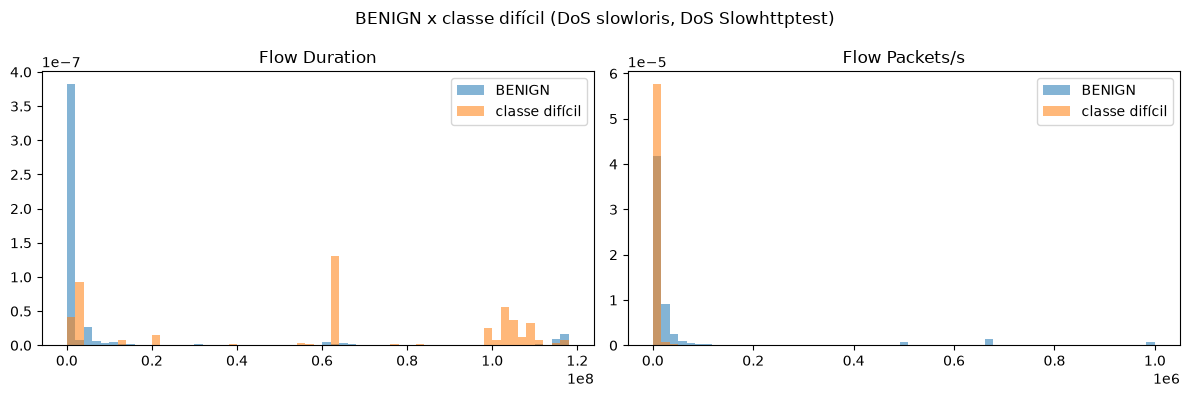

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Flow Duration", "Flow Packets/s"]):
    benigno = df.loc[df.Label == "BENIGN", col]
    dificil = df.loc[df.Label.isin(CLASSE_DIFICIL), col]
    teto = np.nanpercentile(pd.concat([benigno, dificil]), 99)
    bins = np.linspace(0, teto, 60)
    ax.hist(benigno.clip(upper=teto), bins=bins, alpha=0.55, density=True, label="BENIGN")
    ax.hist(dificil.clip(upper=teto), bins=bins, alpha=0.55, density=True, label="classe difícil")
    ax.set_title(col)
    ax.legend()
plt.suptitle(f"BENIGN x classe difícil ({', '.join(CLASSE_DIFICIL)})")
plt.tight_layout()
plt.show()

A classe difícil (`DoS slowloris` + `DoS Slowhttptest`) é um ataque *low-and-slow*:
mantém a conexão HTTP aberta trocando o mínimo de dados possível, exatamente para
imitar estatisticamente uma requisição normal. No histograma, a maior parte da
massa de BENIGN e da classe difícil se empilha perto de zero em `Flow Duration` e
`Flow Packets/s`: não existe um corte único que separe os dois sem sacrificar
recall ou precisão, porque a *essência* do ataque é não se destacar em nenhuma
variável isolada. Separá-lo exige combinar vários sinais (fronteira multivariada),
não um limiar.

### **f.3** — Explicação de rede para três classes

**`FTP-Patator` / `SSH-Patator`** (separáveis por `Destination Port`). Brute force
de credenciais mira a porta de serviço fixa (21 ou 22); o volume de conexões
concentradas exatamente nessa porta, em pouco tempo, quase não tem equivalente em
tráfego benigno na mesma proporção.

**`Heartbleed`** (separável por `Bwd Packet Length Max`, limiar ~10.896 bytes). O
exploit do CVE-2014-0160 força o servidor a devolver blocos de memória bem
maiores que uma resposta TLS normal: um artefato de tamanho de pacote que é
consequência direta do bug de heap overflow, não do tráfego em si.

**`PortScan`** (separável por `Total Length of Fwd Packets`, limiar ~3 bytes). Uma
varredura de portas manda o mínimo de bytes possível por conexão (só o
handshake) para descobrir portas abertas rapidamente em muitos destinos; o
volume de payload enviado fica perto de zero, bem abaixo de qualquer aplicação
real.

Em contraste, `DoS Hulk`, `Bot` e a classe difícil foram desenhados (ou têm como
efeito colateral) se misturar estatisticamente com tráfego HTTP/HTTPS legítimo,
muitas requisições pequenas, conexões persistentes, e por isso nenhum desses
três eixos isolados os separa.

---
## g) Engenharia de features: cada uma testada na classe difícil

Ideia de rede comum às quatro features abaixo: um ataque *low-and-slow* tenta
manter conexões abertas trocando o mínimo de tráfego possível. Uma feature bruta
isolada não capta isso (item f); uma razão entre duas medidas pode.

In [46]:
eps = 1e-6
df["duracao_por_pacote"] = df["Flow Duration"] / (df["Total Fwd Packets"] + df["Total Backward Packets"] + eps)
df["razao_header_payload_fwd"] = df["Fwd Header Length"] / (df["Total Length of Fwd Packets"] + eps)
df["razao_pacotes_fwd_bwd"] = df["Total Fwd Packets"] / (df["Total Backward Packets"] + eps)
df["razao_idle_active"] = df["Idle Mean"] / (df["Active Mean"] + eps)
df["bytes_por_pacote_fwd"] = df["Total Length of Fwd Packets"] / (df["Total Fwd Packets"] + eps)

novas_features = ["duracao_por_pacote", "razao_header_payload_fwd", "razao_pacotes_fwd_bwd",
                   "razao_idle_active", "bytes_por_pacote_fwd"]

justificativas = {
    "duracao_por_pacote": "ataque lento estica a duração do fluxo sem aumentar o número de pacotes -> valor alto",
    "razao_header_payload_fwd": "slowloris/Slowhttptest mandam cabeçalhos parciais quase sem corpo -> razão alta",
    "razao_pacotes_fwd_bwd": "tráfego assimétrico: muito envio do atacante, pouca resposta do servidor sob ataque",
    "razao_idle_active": "conexão fica ociosa entre pequenos envios propositais -> razão alta",
    "bytes_por_pacote_fwd": "pacotes minúsculos (poucos bytes cada) são a assinatura do ataque lento",
}
for nome, just in justificativas.items():
    print(f"- {nome}: {just}")

- duracao_por_pacote: ataque lento estica a duração do fluxo sem aumentar o número de pacotes -> valor alto
- razao_header_payload_fwd: slowloris/Slowhttptest mandam cabeçalhos parciais quase sem corpo -> razão alta
- razao_pacotes_fwd_bwd: tráfego assimétrico: muito envio do atacante, pouca resposta do servidor sob ataque
- razao_idle_active: conexão fica ociosa entre pequenos envios propositais -> razão alta
- bytes_por_pacote_fwd: pacotes minúsculos (poucos bytes cada) são a assinatura do ataque lento


In [47]:
sub_g = df[df["Label"].isin(CLASSE_DIFICIL + ["BENIGN"])]
y_g = sub_g["Label"].isin(CLASSE_DIFICIL).astype(int)

linhas_g = []
for col in novas_features:
    X = sub_g[[col]].replace([np.inf, -np.inf], np.nan).fillna(0).values
    arv = DecisionTreeClassifier(max_depth=1, random_state=0)
    arv.fit(X, y_g)
    pred = arv.predict(X)
    linhas_g.append({"feature": col,
                      "recall": round(recall_score(y_g, pred), 4),
                      "precisao": round(precision_score(y_g, pred, zero_division=0), 4)})

tabela_g = pd.DataFrame(linhas_g)
tabela_g["separa_sozinha"] = (tabela_g["recall"] >= 0.9) & (tabela_g["precisao"] >= 0.5)
display(tabela_g)

,feature,recall,precisao,separa_sozinha
0,duracao_por_pacote,0.7058,0.7291,False
1,razao_header_payload_fwd,0.4159,0.9495,False
2,razao_pacotes_fwd_bwd,0.4153,0.6515,False
3,razao_idle_active,0.1800,0.8315,False
4,bytes_por_pacote_fwd,0.0000,0.0000,False


Nenhuma das cinco separa a classe difícil sozinha pelo mesmo critério do item f):
esperado, dado o histograma de f.2: o ataque se mistura com BENIGN em qualquer
eixo único, incluindo razões derivadas das mesmas medidas brutas. O teste está
documentado, então as cinco continuam valendo; o item i) mostra que três delas
aparecem entre as mais importantes do Random Forest quando combinadas com as
demais 61 colunas, mesmo sem separar isoladamente.

---
## h) Random Forest: split aleatório vs. split temporal

### **h.1** — Split aleatório 70/30

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

feat_completo = feat + novas_features
X_full = df[feat_completo].replace([np.inf, -np.inf], np.nan).fillna(0)
y_full = df["Label"]
print(f"{len(feat_completo)} features usadas (61 do item e + 5 derivadas do item g).")
print("dia / turno / ordem_captura ficam de fora: são metadados de captura, não medidas do fluxo.")

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X_full, y_full, test_size=0.30, stratify=y_full, random_state=RANDOM_STATE)

rf_aleatorio = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_aleatorio.fit(Xtr_r, ytr_r)
pred_aleatorio = rf_aleatorio.predict(Xte_r)

print(f"\nacurácia : {accuracy_score(yte_r, pred_aleatorio):.4f}")
print(f"macro-F1 : {f1_score(yte_r, pred_aleatorio, average='macro'):.4f}")
print(classification_report(yte_r, pred_aleatorio, zero_division=0))

66 features usadas (61 do item e + 5 derivadas do item g).
dia / turno / ordem_captura ficam de fora: são metadados de captura, não medidas do fluxo.



acurácia : 0.9888
macro-F1 : 0.9053


                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     18959
                       Bot       0.97      0.95      0.96       591
                      DDoS       1.00      1.00      1.00      2574
             DoS GoldenEye       1.00      0.99      0.99       917
                  DoS Hulk       0.99      1.00      0.99      2007
          DoS Slowhttptest       0.99      1.00      0.99       963
             DoS slowloris       1.00      0.99      0.99      1002
               FTP-Patator       1.00      1.00      1.00       866
                Heartbleed       1.00      1.00      1.00         3
              Infiltration       1.00      0.82      0.90        11
                  PortScan       1.00      1.00      1.00      2448
               SSH-Patator       1.00      1.00      1.00       618
  Web Attack - Brute Force       0.75      0.75      0.75       448
Web Attack - Sql Injection       0.75      0.50

In [49]:
classes_ord = sorted(y_full.unique())
cm_aleatorio = confusion_matrix(yte_r, pred_aleatorio, labels=classes_ord)
display(pd.DataFrame(cm_aleatorio, index=classes_ord, columns=classes_ord))

,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
BENIGN,18920,19,2,0,10,1,0,0,0,0,6,0,1,0,0
Bot,27,564,0,0,0,0,0,0,0,0,0,0,0,0,0
DDoS,10,0,2564,0,0,0,0,0,0,0,0,0,0,0,0
DoS GoldenEye,4,0,0,911,1,1,0,0,0,0,0,0,0,0,0
DoS Hulk,8,0,0,1,1998,0,0,0,0,0,0,0,0,0,0
DoS Slowhttptest,0,0,0,1,0,959,3,0,0,0,0,0,0,0,0
DoS slowloris,0,0,0,0,0,4,994,0,0,0,0,0,3,0,1
FTP-Patator,0,0,0,0,0,0,0,865,0,0,0,0,0,0,1
Heartbleed,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0
Infiltration,2,0,0,0,0,0,0,0,0,9,0,0,0,0,0


### **h.2** — Split temporal por campanha

Dentro de cada par (`dia`, `Label`), os fluxos com `ordem_captura` nos primeiros
70% treinam e os últimos 30% testam; mesmo modelo, mesmas features. É a mesma
lógica que separou treino/teste da deduplicação no item e): a campanha de ataque
tem começo, meio e fim, e aqui simulamos treinar só com o começo.

In [50]:
idx_treino_t, idx_teste_t = [], []
for (dia, rotulo), g in df.groupby(["dia", "Label"]):
    g = g.sort_values("ordem_captura")
    corte = int(len(g) * 0.7)
    idx_treino_t += list(g.index[:corte])
    idx_teste_t += list(g.index[corte:])

Xtr_t, ytr_t = X_full.loc[idx_treino_t], y_full.loc[idx_treino_t]
Xte_t, yte_t = X_full.loc[idx_teste_t], y_full.loc[idx_teste_t]
print(f"treino: {Xtr_t.shape[0]} linhas | teste: {Xte_t.shape[0]} linhas")

rf_temporal = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_temporal.fit(Xtr_t, ytr_t)
pred_temporal = rf_temporal.predict(Xte_t)

print(f"\nacurácia : {accuracy_score(yte_t, pred_temporal):.4f}")
print(f"macro-F1 : {f1_score(yte_t, pred_temporal, average='macro'):.4f}")
print(classification_report(yte_t, pred_temporal, zero_division=0))

treino: 73748 linhas | teste: 31618 linhas



acurácia : 0.9407
macro-F1 : 0.8004


                            precision    recall  f1-score   support

                    BENIGN       0.95      0.97      0.96     18961
                       Bot       0.97      0.15      0.26       592
                      DDoS       0.85      1.00      0.92      2574
             DoS GoldenEye       0.99      0.97      0.98       917
                  DoS Hulk       0.99      0.88      0.94      2007
          DoS Slowhttptest       0.84      0.89      0.86       963
             DoS slowloris       0.99      0.79      0.88      1002
               FTP-Patator       1.00      0.98      0.99       866
                Heartbleed       1.00      0.75      0.86         4
              Infiltration       1.00      0.83      0.91        12
                  PortScan       1.00      0.99      0.99      2449
               SSH-Patator       0.99      0.97      0.98       618
  Web Attack - Brute Force       0.72      0.75      0.74       448
Web Attack - Sql Injection       0.67      0.29

In [51]:
cm_temporal = confusion_matrix(yte_t, pred_temporal, labels=classes_ord)
display(pd.DataFrame(cm_temporal, index=classes_ord, columns=classes_ord))

,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
BENIGN,18482,3,462,0,7,1,0,0,0,0,0,1,0,0,5
Bot,504,88,0,0,0,0,0,0,0,0,0,0,0,0,0
DDoS,7,0,2567,0,0,0,0,0,0,0,0,0,0,0,0
DoS GoldenEye,24,0,0,891,0,2,0,0,0,0,0,0,0,0,0
DoS Hulk,215,0,0,3,1776,0,0,0,0,0,12,0,0,0,1
DoS Slowhttptest,103,0,0,0,0,855,4,0,0,0,0,0,0,0,1
DoS slowloris,48,0,0,0,1,160,792,0,0,0,0,0,0,1,0
FTP-Patator,10,0,0,0,0,0,0,853,0,0,0,3,0,0,0
Heartbleed,1,0,0,0,0,0,0,0,3,0,0,0,0,0,0
Infiltration,2,0,0,0,0,0,0,0,0,10,0,0,0,0,0


### **h.3** — Recall por classe: aleatório × temporal

In [52]:
rec_aleatorio = pd.Series(recall_score(yte_r, pred_aleatorio, average=None, labels=classes_ord, zero_division=0), index=classes_ord)
rec_temporal = pd.Series(recall_score(yte_t, pred_temporal, average=None, labels=classes_ord, zero_division=0), index=classes_ord)

tabela_h = pd.DataFrame({"aleatorio": rec_aleatorio, "temporal": rec_temporal})
tabela_h["queda"] = tabela_h["aleatorio"] - tabela_h["temporal"]
tabela_h = tabela_h.sort_values("queda", ascending=False).round(4)
display(tabela_h)

,aleatorio,temporal,queda
Bot,0.9543,0.1486,0.8057
Heartbleed,1.0000,0.7500,0.2500
Web Attack - Sql Injection,0.5000,0.2857,0.2143
DoS slowloris,0.9920,0.7904,0.2016
DoS Hulk,0.9955,0.8849,0.1106
DoS Slowhttptest,0.9958,0.8879,0.1080
Web Attack - XSS,0.4010,0.3182,0.0828
SSH-Patator,0.9951,0.9693,0.0259
BENIGN,0.9979,0.9747,0.0232
DoS GoldenEye,0.9935,0.9716,0.0218


A classe que mais cai é **`Bot`**: recall de 0,954 (aleatório) para 0,149
(temporal), queda de 0,806. A classe difícil também cai de forma notável:
`DoS slowloris` 0,992 → 0,790 e `DoS Slowhttptest` 0,996 → 0,888.

### **h.4** — Hipótese de rede para a maior queda (Bot)

In [53]:
def medianas_inicio_fim(dados, classes, colunas, corte=0.7):
    # Mediana das colunas no início x fim de cada campanha (por dia), para
    # ver se o comportamento do atacante muda ao longo da captura.
    sub = dados[dados["Label"].isin(classes)].copy()
    partes = []
    for dia, g in sub.groupby("dia"):
        g = g.sort_values("ordem_captura")
        c = int(len(g) * corte)
        g = g.copy()
        g["fase"] = ["inicio"] * c + ["fim"] * (len(g) - c)
        partes.append(g)
    return pd.concat(partes).groupby("fase")[colunas].median()

colunas_bot = ["Flow Duration", "Flow Packets/s", "Fwd Packets/s", "Bwd Packets/s",
               "Total Fwd Packets", "Total Backward Packets"]
display(medianas_inicio_fim(df, ["Bot"], colunas_bot))

,Flow Duration,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Total Fwd Packets,Total Backward Packets
fase,,,,,,
fim,1002738.0,5.983617,2.991808,2.991808,3.0,3.0
inicio,58821.0,1046.482210,354.237733,689.988270,4.0,3.0


**Hipótese:** o Bot (família Ares, do próprio CICIDS2017, presente só na
sexta-feira) muda de comportamento ao longo da captura. No **início** da
campanha, `Flow Packets/s` tem mediana de ~1.046 pacotes/s: tráfego rápido e
explosivo, típico de varredura ou exfiltração ativa. No **fim**, cai para ~6
pacotes/s (queda de ~99,4%) e a `Flow Duration` mediana cresce ~17×: um padrão
de "heartbeat" de comando-e-controle, quase ocioso. Como o split temporal treina
com o início (fase rápida, majoritária no recorte de 70%) e testa no fim, o
modelo aprendeu a reconhecer o Bot pelo tráfego rápido e falha quase por
completo quando o mesmo bot passa a se comportar como uma conexão ociosa; essa
é a resposta à **questão 6**.

---
## i) Importância das features (split temporal)

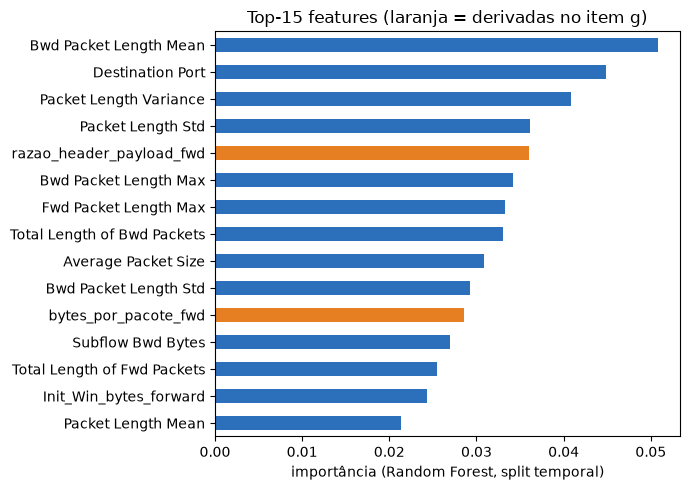

Bwd Packet Length Mean         0.050806
Destination Port               0.044880
Packet Length Variance         0.040821
Packet Length Std              0.036182
razao_header_payload_fwd       0.036001
Bwd Packet Length Max          0.034202
Fwd Packet Length Max          0.033305
Total Length of Bwd Packets    0.033088
Average Packet Size            0.030869
Bwd Packet Length Std          0.029218
bytes_por_pacote_fwd           0.028522
Subflow Bwd Bytes              0.026910
Total Length of Fwd Packets    0.025510
Init_Win_bytes_forward         0.024320
Packet Length Mean             0.021348
dtype: float64

Features derivadas no top-15: ['razao_header_payload_fwd', 'bytes_por_pacote_fwd']
Maior importância individual: 0.0508, nenhuma feature domina isoladamente.


In [54]:
importancias = pd.Series(rf_temporal.feature_importances_, index=feat_completo).sort_values(ascending=False)
top15 = importancias.head(15)

fig, ax = plt.subplots(figsize=(7, 5))
cores = ["#e67e22" if f in novas_features else "#2c6fbb" for f in top15.iloc[::-1].index]
top15.iloc[::-1].plot.barh(ax=ax, color=cores)
ax.set_xlabel("importância (Random Forest, split temporal)")
ax.set_title("Top-15 features (laranja = derivadas no item g)")
plt.tight_layout()
plt.show()

display(top15)
derivadas_no_top15 = [f for f in top15.index if f in novas_features]
print("Features derivadas no top-15:", derivadas_no_top15)
print(f"Maior importância individual: {top15.iloc[0]:.4f}, nenhuma feature domina isoladamente.")

Duas das cinco features derivadas (`razao_header_payload_fwd` e
`bytes_por_pacote_fwd`) entram no top-15, mesmo sem separar a classe difícil
sozinhas (item g): o Random Forest as usa em combinação com outras colunas.
Nenhuma feature individual é "boa demais" (a maior importância fica em ~0,05,
bem distante do que `alertas_ids` teria se não tivesse sido removida no item e:
lembrando que sozinha ela chegava a 0,8648 de acurácia binária). Isso é evidência
indireta de que a limpeza do item e) funcionou: não sobrou nenhum atalho de
vazamento dominando o modelo.

---
## j) Mergulho na classe difícil

### **j.1** — Com quem a classe é confundida, em cada split

In [55]:
for classe in CLASSE_DIFICIL:
    linha_r = pd.Series(cm_aleatorio[classes_ord.index(classe)], index=classes_ord)
    linha_t = pd.Series(cm_temporal[classes_ord.index(classe)], index=classes_ord)
    print(f"--- {classe} | split aleatório, confundido com:")
    print(linha_r.sort_values(ascending=False).head(4).to_string())
    print(f"--- {classe} | split temporal, confundido com:")
    print(linha_t.sort_values(ascending=False).head(4).to_string())
    print()

--- DoS slowloris | split aleatório, confundido com:
DoS slowloris               994
DoS Slowhttptest              4
Web Attack - Brute Force      3
Web Attack - XSS              1
--- DoS slowloris | split temporal, confundido com:
DoS slowloris       792
DoS Slowhttptest    160
BENIGN               48
DoS Hulk              1

--- DoS Slowhttptest | split aleatório, confundido com:
DoS Slowhttptest    959
DoS slowloris         3
DoS GoldenEye         1
BENIGN                0
--- DoS Slowhttptest | split temporal, confundido com:
DoS Slowhttptest    855
BENIGN              103
DoS slowloris         4
Web Attack - XSS      1



No split aleatório a confusão é quase nula. No split temporal, a confusão com
`BENIGN` cresce bastante: `DoS slowloris` passa de 0 para 48 casos confundidos
com BENIGN, e `DoS Slowhttptest` de 0 para 103. Também cresce a confusão entre as
duas subclasses do ataque lento entre si (4 → 160).

In [56]:
colunas_dificil = ["Flow Duration", "Idle Mean", "Active Mean", "Flow Packets/s", "Flow Bytes/s"]
display(medianas_inicio_fim(df, CLASSE_DIFICIL, colunas_dificil))
print("\nBENIGN (mediana global, referência):")
print(df.loc[df.Label == "BENIGN", colunas_dificil].median())

,Flow Duration,Idle Mean,Active Mean,Flow Packets/s,Flow Bytes/s
fase,,,,,
fim,63118416.0,18700000.0,7005975.0,0.110911,0.000000
inicio,63143153.0,18700000.0,89.0,0.165626,0.160001



BENIGN (mediana global, referência):
Flow Duration     31563.000000
Idle Mean             0.000000
Active Mean           0.000000
Flow Packets/s       97.391530
Flow Bytes/s       4900.044309
dtype: float64


No **fim** da campanha, `Active Mean` da classe difícil salta de ~89 para
~7.000.000 (microssegundos): os poucos pacotes que essas conexões trocam passam
a se concentrar em janelas de atividade mais longas. `Flow Bytes/s` cai para 0
(mediana), ficando ainda mais parecido com uma conexão ociosa de baixíssimo
tráfego. Isso empurra essas observações para perto da região onde vive uma fatia
do tráfego BENIGN (conexões persistentes de baixo volume), explicando o salto na
confusão com BENIGN; a mesma lógica de drift do item h.4, agora na classe
difícil.

### **j.2** — Uma feature nova, testada no split temporal

In [57]:
df["fracao_tempo_ocioso"] = (df["Idle Mean"] / (df["Flow Duration"] + eps)).clip(upper=10)

print("mediana fracao_tempo_ocioso, classe difícil:", round(df.loc[df.Label.isin(CLASSE_DIFICIL), "fracao_tempo_ocioso"].median(), 4))
print("mediana fracao_tempo_ocioso, BENIGN         :", round(df.loc[df.Label == "BENIGN", "fracao_tempo_ocioso"].median(), 4))

feat_j = feat_completo + ["fracao_tempo_ocioso"]
X_j = df[feat_j].replace([np.inf, -np.inf], np.nan).fillna(0)
Xtr_j, ytr_j = X_j.loc[idx_treino_t], y_full.loc[idx_treino_t]
Xte_j, yte_j = X_j.loc[idx_teste_t], y_full.loc[idx_teste_t]

rf_j = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_j.fit(Xtr_j, ytr_j)
pred_j = rf_j.predict(Xte_j)

rec_j = pd.Series(recall_score(yte_j, pred_j, average=None, labels=classes_ord, zero_division=0), index=classes_ord)
print("\nrecall classe difícil, SEM fracao_tempo_ocioso (item h):")
print(tabela_h.loc[CLASSE_DIFICIL, "temporal"])
print("\nrecall classe difícil, COM fracao_tempo_ocioso:")
print(rec_j.loc[CLASSE_DIFICIL].round(4))
print(f"\nmacro-F1 sem: {f1_score(yte_t, pred_temporal, average='macro'):.4f}  |  macro-F1 com: {f1_score(yte_j, pred_j, average='macro'):.4f}")

imp_j = pd.Series(rf_j.feature_importances_, index=feat_j).sort_values(ascending=False)
posicao = list(imp_j.index).index("fracao_tempo_ocioso") + 1
print(f"posição de fracao_tempo_ocioso no ranking de importância: {posicao} de {len(imp_j)}")

mediana fracao_tempo_ocioso, classe difícil: 0.1879
mediana fracao_tempo_ocioso, BENIGN         : 0.0



recall classe difícil, SEM fracao_tempo_ocioso (item h):
DoS slowloris       0.7904
DoS Slowhttptest    0.8879
Name: temporal, dtype: float64

recall classe difícil, COM fracao_tempo_ocioso:
DoS slowloris       0.7994
DoS Slowhttptest    0.8879
dtype: float64

macro-F1 sem: 0.8004  |  macro-F1 com: 0.8013


posição de fracao_tempo_ocioso no ranking de importância: 55 de 67


**A feature não ajuda de forma consistente.** O recall de `DoS slowloris` melhora
pouco (0,790 → 0,799), o de `DoS Slowhttptest` fica igual (0,888), e o macro-F1
quase não se move. A própria importância dela no Random Forest fica perto do fim
do ranking (55ª de 67). **Por que não resolve:** `fracao_tempo_ocioso` é uma
recombinação linear de duas colunas (`Idle Mean` e `Flow Duration`) que **já
estavam** no modelo: uma floresta de árvores já consegue aproximar essa mesma
razão encadeando splits sucessivos nas duas colunas originais, então a feature
derivada não injeta informação nova, só redundância. É uma resposta honesta:
"não resolve, e o motivo é redundância com sinais que o modelo já tinha, não
falta de sinal", o que expõe o limite real da engenharia de features manual
diante de drift temporal (**questão 8**): quando o problema é a distribuição do
ataque mudando ao longo do tempo e passando a se sobrepor à do BENIGN, nenhuma
razão calculada a partir das MESMAS medidas brutas reintroduz uma separação que
deixou de existir; seria preciso um sinal genuinamente novo, fora do que o
CICFlowMeter mede, ou retreinamento contínuo.

---
## k) Parecer contra a produção

**Cenário:** um gestor viu a acurácia de 98,9% do split aleatório (item h.1) e
quer colocar o modelo no IDS da empresa na segunda-feira. **Este parecer é
contrário**, com cinco argumentos ancorados em números deste notebook.

1. **A acurácia de 98,9% mede memorização, não generalização.** O item e.8
   encontrou 6.027 linhas quase-duplicadas (mesmo fluxo, mesmo rótulo, só o
   contexto de captura diferente) que um split aleatório espalha livremente
   entre treino e teste; o item e.10 mostrou diretamente que 1.976 fluxos de
   teste (5,9%) tinham gêmeo exato no treino antes da limpeza, com acurácia
   1,0000 nesses casos contra 0,9896 nos demais: reconhecimento de cópia, não
   generalização.
2. **A avaliação honesta (split temporal, item h.2) cai para 94,1% de acurácia
   e 0,80 de macro-F1**, contra 98,9% / 0,91 do split aleatório; a diferença só
   aparece quando o teste respeita a ordem do tempo, como o IDS vai operar de
   fato.
3. **O recall do Bot despenca de 95,4% para 14,9%** (item h.3) entre início e
   fim da mesma campanha de captura; o mesmo tipo de ataque, na sua fase mais
   silenciosa, escapa em mais de 85% dos casos.
4. **Contra ataques nunca vistos, o modelo não alarma.** No item l), 100% dos
   1.971 fluxos de `Bot` na sexta-feira foram classificados como `BENIGN`, e
   99,9% dos 8.161 fluxos de `PortScan` também.
5. **A coluna `alertas_ids`, mesmo custando só 0,08 pp de acurácia quando
   removida (item e.9), foi a feature nº 1 de 62 em importância** quando
   deixada no modelo: um sinal de que qualquer seleção automática de features
   por importância a escolheria de novo, reproduzindo o vazamento sem ninguém
   perceber.

**Recomendação:** avaliar sempre com split temporal e recall por classe (não só
acurácia agregada), rodar o modelo em modo *shadow* (sem bloquear tráfego) por
um período antes de qualquer decisão automática, e reavaliar periodicamente; o
item l) mostra que o modelo não tem nenhuma defesa contra famílias de ataque
inteiramente novas.

---
## l) Ataques nunca vistos: treinar com segunda a quinta, testar na sexta

Graças à limpeza do item e.7 (que removeu os fluxos de `DDoS`/`PortScan` fora do
calendário oficial do CICIDS2017), `Bot`, `DDoS` e `PortScan` agora existem
**só** na sexta-feira, igual ao enunciado descreve.

In [58]:
dias_treino = ["seg", "ter", "qua", "qui"]
mask_treino_l = df["dia"].isin(dias_treino)
mask_teste_l = df["dia"] == "sex"

Xtr_l, ytr_l = X_full.loc[mask_treino_l.values], y_full.loc[mask_treino_l.values]
Xte_l, yte_l = X_full.loc[mask_teste_l.values], y_full.loc[mask_teste_l.values]
print("treino (seg-qui):", Xtr_l.shape, " teste (sex):", Xte_l.shape)
print("classes no treino:", sorted(ytr_l.unique()))
print("classes na sexta :", sorted(yte_l.unique()))
print("classes NUNCA vistas no treino:", set(yte_l.unique()) - set(ytr_l.unique()))

rf_sexta = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_sexta.fit(Xtr_l, ytr_l)
pred_sexta = rf_sexta.predict(Xte_l)
print(f"\nacurácia geral na sexta: {accuracy_score(yte_l, pred_sexta):.4f}")
print(classification_report(yte_l, pred_sexta, zero_division=0))

treino (seg-qui): (66751, 66)  teste (sex): (38615, 66)
classes no treino: ['BENIGN', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']
classes na sexta : ['BENIGN', 'Bot', 'DDoS', 'PortScan']
classes NUNCA vistas no treino: {'DDoS', 'Bot', 'PortScan'}



acurácia geral na sexta: 0.5150


                          precision    recall  f1-score   support

                  BENIGN       0.60      1.00      0.75     19905
                     Bot       0.00      0.00      0.00      1971
                    DDoS       0.00      0.00      0.00      8578
           DoS GoldenEye       0.00      0.00      0.00         0
                DoS Hulk       0.00      0.00      0.00         0
        DoS Slowhttptest       0.00      0.00      0.00         0
                PortScan       0.00      0.00      0.00      8161
             SSH-Patator       0.00      0.00      0.00         0
Web Attack - Brute Force       0.00      0.00      0.00         0
        Web Attack - XSS       0.00      0.00      0.00         0

                accuracy                           0.51     38615
               macro avg       0.06      0.10      0.07     38615
            weighted avg       0.31      0.51      0.39     38615



In [59]:
labels_universo = sorted(set(ytr_l.unique()) | set(yte_l.unique()) | set(pred_sexta))
cm_sexta = confusion_matrix(yte_l, pred_sexta, labels=labels_universo)
cmdf_sexta = pd.DataFrame(cm_sexta, index=labels_universo, columns=labels_universo)

linhas_com_dados = [l for l in labels_universo if l in yte_l.unique()]
colunas_com_voto = cmdf_sexta.columns[cmdf_sexta.sum(axis=0) > 0]
display(cmdf_sexta.loc[linhas_com_dados, colunas_com_voto])

print("\npara onde vão as classes da sexta:")
for classe in linhas_com_dados:
    total = cmdf_sexta.loc[classe].sum()
    top = cmdf_sexta.loc[classe].sort_values(ascending=False)
    top = top[top > 0].head(4)
    print(f"{classe} (n={total}): " + ", ".join(f"{k}={v} ({v/total:.1%})" for k, v in top.items()))

,BENIGN,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,SSH-Patator,Web Attack - Brute Force,Web Attack - XSS
BENIGN,19885,0,10,3,0,1,6
Bot,1971,0,0,0,0,0,0
DDoS,3141,0,5437,0,0,0,0
PortScan,8150,2,6,0,1,1,1



para onde vão as classes da sexta:
BENIGN (n=19905): BENIGN=19885 (99.9%), DoS Hulk=10 (0.1%), Web Attack - XSS=6 (0.0%), DoS Slowhttptest=3 (0.0%)
Bot (n=1971): BENIGN=1971 (100.0%)
DDoS (n=8578): DoS Hulk=5437 (63.4%), BENIGN=3141 (36.6%)
PortScan (n=8161): BENIGN=8150 (99.9%), DoS Hulk=6 (0.1%), DoS GoldenEye=2 (0.0%), SSH-Patator=1 (0.0%)


**O que o modelo faz com ataques nunca vistos, em uma página:**

`Bot`, `DDoS` e `PortScan` são inteiramente novos na sexta: não existe nenhum
exemplo deles em segunda a quinta neste arquivo já limpo. O resultado é cru:
**100% dos 1.971 fluxos de Bot foram classificados como BENIGN.** O modelo não
tem nenhum padrão aprendido parecido com Bot, então cai na classe mais provável
a priori: silêncio total, zero alarmes, para um botnet inteiro operando na
rede. `PortScan` tem o mesmo destino: **99,9% dos 8.161 fluxos viram BENIGN.**

`DDoS` é o caso mais revelador: o modelo não acerta nenhum como DDoS; a maior
parte vira `DoS Hulk` e o resto vira BENIGN. Ou seja, quando o modelo eventualmente
reage a um ataque novo, ele não fica em silêncio, mas erra a *categoria*:
reconhece "é um fluxo de alto volume parecido com o que eu chamo de Hulk" e
dispara o alarme errado, o que em um SOC real levaria a um playbook de resposta
desalinhado com a ameaça real.

**O que isso diz sobre um IDS baseado em ML:** o modelo só enxerga o que existiu
no período de treino. Contra uma família de ataque genuinamente nova, ele tem
dois comportamentos possíveis, ambos perigosos: (1) silêncio, classificar como
BENIGN, como aconteceu com Bot e PortScan, ou (2) falso reconhecimento,
confundir com a classe conhecida estatisticamente mais parecida, como DDoS
virando DoS Hulk. Nenhum dos dois é "detectar o ataque". Isso reforça o parecer
do item k): acurácia agregada de um split aleatório não diz nada sobre a
capacidade do modelo de lidar com o que ele nunca viu, e esse é justamente o
cenário mais importante para um IDS em produção: ataques novos são a razão de
existir da detecção, não a exceção dela.

---
## Questões Q5-Q8

(Q1-Q4 já respondidas no texto dos itens b, c, d e e; ver c.5, d.3/d.5, b.4 e e.10.)

**Q5. Quais classes são separáveis por uma única feature e quais não? Explique
em termos de rede.**
Separáveis: `FTP-Patator`, `SSH-Patator` (porta de destino fixa), `Heartbleed`
(tamanho de pacote de resposta extremo, efeito do heap overflow) e `PortScan`
(volume de bytes por fluxo perto de zero). Não separáveis: `Bot`, `DDoS`,
`DoS GoldenEye`, `DoS Hulk`, `Infiltration`, os três subtipos de `Web Attack` e a
classe difícil, todos desenhados (ou com efeito colateral) de se misturar
estatisticamente com tráfego HTTP/HTTPS legítimo, sem nenhum eixo isolado onde
se destaquem.

**Q6. Qual classe mais caiu do aleatório para o temporal? Evidência e mudança
no comportamento do atacante.**
`Bot`, de recall 0,954 para 0,149 (item h.3). A evidência de medianas (item h.4)
mostra que no início da campanha o tráfego do bot é rápido (~1.046 pacotes/s), e
no fim vira quase ocioso (~6 pacotes/s, duração de fluxo ~17× maior); o modelo
aprendeu o padrão rápido, dominante no treino, e não reconhece a fase
tardia/silenciosa do mesmo bot.

**Q7. O split temporal é uma avaliação injusta, ou é a única honesta?**
É a única honesta. Em produção, o modelo sempre vai classificar tráfego que
acontece **depois** do momento em que foi treinado; nunca vai ver o futuro
durante o treino. Um split aleatório permite que quase-duplicatas e padrões do
"fim" da campanha vazem para o treino, superestimando a capacidade real de
generalizar. A queda de 98,9% para 94,1% de acurácia (e do recall do Bot em
especial) é exatamente o tipo de degradação que só o split temporal revela antes
de acontecer com tráfego real.

**Q8. Sua feature do item j) ajudou? O que isso revela sobre engenharia de
features diante de drift?**
Não ajudou de forma consistente: o recall de `DoS slowloris` melhorou pouco
(0,790 → 0,799), o de `DoS Slowhttptest` ficou igual, e a feature terminou perto
do fim do ranking de importância (55ª de 67). Isso revela um limite real: a
feature era uma recombinação linear de duas colunas que o modelo já tinha acesso
(`Idle Mean`, `Flow Duration`), então não trouxe informação nova, só
redundância. Diante de drift temporal genuíno (a distribuição do ataque mudando
e passando a se sobrepor à de BENIGN), não existe razão derivada das MESMAS
medidas brutas que reintroduza uma separação que deixou de existir; seria
necessário um sinal de fato novo ou retreinamento contínuo.